Installations

In [2]:
import pandas as pd
import pytz
import re
import unicodedata
import nltk
import json
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
from nltk.corpus import stopwords
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.sparse import csr_matrix

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\fatim\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\fatim\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\fatim\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


commnets

In [8]:
comments = pd.read_csv('instagram_comments.csv')
data = comments.loc[:,['post_id','created_at','username','text','parent_comment_id']]
data

,post_id,created_at,username,text,parent_comment_id
0,DQ51a5oEw2y,1762841875,heframid,Selamat ulang tahun ke-36 Harian Surya! 🎉 Semo...,NaN
1,DQ51a5oEw2y,1762844716,pdamsuryasembada,@heframid Terima kasih Heframid. Semoga sukses...,NaN
2,DQ51a5oEw2y,1762868957,kharistiano28,👏👏👏 selalu menjalin kerjasama yg baik dgn medi...,NaN
3,DQ51a5oEw2y,1762904139,pdamsuryasembada,@kharistiano28 terima kasih Bpk Kharistiano at...,NaN
4,DQ5v5UsE4As,1762834417,mhmdrizkyy12._,Selamatt dan semangattt indonesiaku😍🔥,NaN
...,...,...,...,...,...
27651,Czvi08FPNgg,1700223629,pdamsuryasembada,@pratyaharasamadhi selamat malam pak mhn infor...,NaN
27652,Czvi08FPNgg,1700223639,pdamsuryasembada,"@hellow_vee92 Selamat malam pak/bu, mohon maaf...",NaN
27653,Czvi08FPNgg,1700223644,pdamsuryasembada,"@hellow_vee92 Selamat malam pak/bu, mohon maaf...",NaN
27654,Czvi08FPNgg,1700223839,pdamsuryasembada,"@vii.4dity Selamat malam pak/bu, mohon maaf at...",NaN


Drop empty comments
Remove comments from pdamsuryasembada
Change date from epoch miliseconds
Remove taggings from comments

In [9]:
data = data[data['username'].str.contains('pdamsuryasembada') == False]

data = data.drop_duplicates(subset=['text'])

local_timezone = pytz.timezone('Asia/Jakarta')
data['created_at'] = pd.to_datetime(data['created_at'], unit='s')
data['created_at'] = data['created_at'].dt.tz_localize('UTC').dt.tz_convert(local_timezone)
data['created_at'] = data['created_at'].dt.strftime('%Y-%m-%d %H:%M:%S %Z')

def remove_tags(text):
    if not isinstance(text, str):
        return ""
    return re.sub(r'@\w[\w\.]*', '', text).strip()

data['text'] = data['text'].apply(remove_tags)

data = data.dropna(subset=["text"])
data = data[data["text"].astype(str).str.strip() != ""]

cleaning

In [10]:
PUNCT_TO_REMOVE = "!#$%&()*+,./:;<=>@[\\]^_{|}~`"
def remove_punctuation(text):
    """custom function to remove the punctuation"""
    return text.translate(str.maketrans('', '', PUNCT_TO_REMOVE))

data["text"] = data["text"].apply(lambda text: remove_punctuation(text))

def remove_emojis(text):
    """Removes standard unicode emojis from the text."""
    if not isinstance(text, str):
        return text

    emoji_pattern = re.compile(
        "["                     
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U0001F700-\U0001F77F"
        u"\U0001F780-\U0001F7FF"
        u"\U0001F800-\U0001F8FF"
        u"\U0001F900-\U0001F9FF"
        u"\U0001FA70-\U0001FAFF"
        u"\u2600-\u26FF"
        u"\u2700-\u27BF"
        u"\ufe0f"
        "]+",
        flags=re.UNICODE,
    )

    return emoji_pattern.sub(r'', text)

data['text'] = data['text'].apply(remove_emojis)
data['text'] = data['text'].str.strip()

def normalize_fancy_unicode(text):
    if not isinstance(text, str):
        return text

    normalized = unicodedata.normalize("NFKD", text)

    cleaned = "".join(
        ch for ch in normalized
        if not unicodedata.combining(ch)
    )
    return cleaned

data["text"] = data["text"].apply(normalize_fancy_unicode)

data = data.dropna(subset=["text"])
data = data[data["text"].astype(str).str.strip() != ""]

case folding

In [11]:
data["text"] = data["text"].str.lower()

tokem

In [12]:
data['text'] = data['text'].astype(str).apply(word_tokenize)

In [13]:
def is_all_numbers(tokens):
    return all(re.fullmatch(r'\d+', tok) for tok in tokens)

data = data[~data['text'].apply(is_all_numbers)]


def normalize_mixed_number_token(token):
    if re.fullmatch(r'\d+', token):
        return "<num>"
    
    parts = re.findall(r'\d+|[a-zA-Z]+', token)

    if len(parts) == 1:
        return token

    parts = ["<num>" if p.isdigit() else p for p in parts]

    return " ".join(parts)


def normalize_tokens(token_list):
    normalized = []
    for tok in token_list:
        if tok.isdigit():
            normalized.append("<num>")
        elif re.search(r'\d', tok):
            normalized.append(normalize_mixed_number_token(tok))
        else:
            normalized.append(tok)
    return normalized

data["text"] = data["text"].apply(normalize_tokens)

In [14]:
data_partial = data.copy()
data_partial.to_csv('all_tokenized_v3.csv', index=False)
# data_partial = pd.read_csv('all_tokenized_v2.csv')
data_partial
# data_oct = data[(data['created_at'] > '2025-10-01') & (data['created_at'] < '2025-11-01')]
# data_sept = data[(data['created_at'] > '2025-09-01') & (data['created_at'] < '2025-10-01')]
# # data_sept.to_csv('september_comments.csv', index=False)
# data_partial = data_oct.copy()


# the partial thing will be done after stemming, for preparation of demo

,post_id,created_at,username,text,parent_comment_id
0,DQ51a5oEw2y,2025-11-11 13:17:55 WIB,heframid,"[selamat, ulang, tahun, ke <num>, harian, sury...",NaN
2,DQ51a5oEw2y,2025-11-11 20:49:17 WIB,kharistiano28,"[selalu, menjalin, kerjasama, yg, baik, dgn, m...",NaN
4,DQ5v5UsE4As,2025-11-11 11:13:37 WIB,mhmdrizkyy12._,"[selamatt, dan, semangattt, indonesiaku]",NaN
6,DQ5ldh8E_V7,2025-11-11 09:48:57 WIB,panggilnaw,"[dm, ku, ga, dibales, kak]",NaN
9,DQ6J9gWE8rk,2025-11-11 16:04:18 WIB,baang_aziz,"[salam, buat, tim, spi, min]",NaN
...,...,...,...,...,...
27646,Czvi08FPNgg,2023-11-17 17:26:00 WIB,pratyaharasamadhi,"[ancen, tumanbanyu, mati, ra, kondo <num>, dis...",NaN
27647,Czvi08FPNgg,2023-11-17 17:42:18 WIB,bapakduaanak,"[sak, jane, laporane, wong <num>, iki, bener <...",NaN
27648,Czvi08FPNgg,2023-11-17 17:43:46 WIB,qenndra,"[kebiasaan, pdam, klo, mati, gk, woro <num>, d...",NaN
27649,Czvi08FPNgg,2023-11-17 17:46:33 WIB,insomnila,"[sudah, lapor, tapi, belum, nyala, seharian]",NaN


formalize

In [15]:
with open("dictionary/dict_template3_doneig.json", "r", encoding="utf-8") as f:
    formal_dict3 = json.load(f)

with open("dictionary/dict4.json", "r", encoding="utf-8") as f:
    formal_dict4 = json.load(f)

formal_dict = {**formal_dict3, **formal_dict4}

def apply_formalization(tokens, formal_dict):
    
    new_tokens = []
    for tok in tokens:
        if tok in formal_dict:
            replacement = formal_dict[tok]
            new_tokens.extend(replacement.split())
            # new_tokens.append(formal_dict[tok]) 
        else:
            new_tokens.append(tok)
    return new_tokens

data_partial["text"] = data_partial["text"].apply(lambda tokens: apply_formalization(tokens, formal_dict))

In [31]:
data_partial

,post_id,created_at,username,text,parent_comment_id
0,DQ51a5oEw2y,2025-11-11 13:17:55 WIB,heframid,"[selamat, ulang, tahun, ke <num>, harian, sury...",NaN
2,DQ51a5oEw2y,2025-11-11 20:49:17 WIB,kharistiano28,"[selalu, menjalin, kerjasama, yg, baik, dgn, m...",NaN
4,DQ5v5UsE4As,2025-11-11 11:13:37 WIB,mhmdrizkyy12._,"[selamat, dan, semangat, indonesia]",NaN
6,DQ5ldh8E_V7,2025-11-11 09:48:57 WIB,panggilnaw,"[dm, ku, ga, balas, kak]",NaN
9,DQ6J9gWE8rk,2025-11-11 16:04:18 WIB,baang_aziz,"[salam, buat, tim, spi, min]",NaN
...,...,...,...,...,...
27646,Czvi08FPNgg,2023-11-17 17:26:00 WIB,pratyaharasamadhi,"[ancen, tuman, air, mati, ra, bilang, panas, n...",NaN
27647,Czvi08FPNgg,2023-11-17 17:42:18 WIB,bapakduaanak,"[sak, seharusnya, lapor, iki, benar-benar, di,...",NaN
27648,Czvi08FPNgg,2023-11-17 17:43:46 WIB,qenndra,"[kebiasaan, pdam, klo, mati, gk, pengumuman, d...",NaN
27649,Czvi08FPNgg,2023-11-17 17:46:33 WIB,insomnila,"[sudah, lapor, tapi, belum, nyala, seharian]",NaN


delete stopwor

In [16]:
with open('stopwords_v3.txt', 'r', encoding='utf-8') as f:
    custom_stopwords = set([line.strip() for line in f if line.strip()])

def remove_stopwords(tokens, stopword_set):
    return [tok for tok in tokens if tok not in stopword_set and tok.strip() != ""]

data_partial["text"] = data_partial["text"].apply(lambda tokens: remove_stopwords(tokens, custom_stopwords))

stemmming

In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.Stemmer.Stemmer import Stemmer
from Sastrawi.Stemmer.CachedStemmer import CachedStemmer
from Sastrawi.Stemmer.Cache.ArrayCache import ArrayCache
from Sastrawi.Dictionary.ArrayDictionary import ArrayDictionary

PROTECTED_WORDS = [
    'sememi',
]

factory = StemmerFactory()
base_words = factory.get_words_from_file()
combined_words = list(set(base_words + PROTECTED_WORDS))
custom_dict = ArrayDictionary(combined_words)
stemmer = CachedStemmer(ArrayCache(), Stemmer(custom_dict))

def stem_tokens(tokens):
    if not isinstance(tokens, list):
        return tokens
    return [stemmer.stem(tok) for tok in tokens]

data_partial["text"] = data_partial["text"].apply(stem_tokens)

In [18]:
data_partial.to_csv("stemmed_all_v5.csv", index=False)

In [3]:
comments = pd.read_csv('stemmed_all_v5.csv')
data_partial = comments.loc[:,['post_id','created_at','username','text']]
data_partial = data_partial[(data_partial['created_at'] > '2025-10-01') & (data_partial['created_at'] < '2025-11-01')]
import ast

data_partial['text'] = data_partial['text'].apply(ast.literal_eval)
data_partial
# data_partial.to_csv("stemmed_oct2025.csv", index=False)

,post_id,created_at,username,text
10,DPiRgn6k9BI,2025-10-29 23:44:51 WIB,n_aiiniiii,"[paham, harga, pasang, pdam]"
11,DPiRgn6k9BI,2025-10-30 05:38:39 WIB,raymundus_aryo,[rame]
12,DPiRgn6k9BI,2025-10-31 04:47:10 WIB,opera8176,"[pdam, jalan, gresik, mati]"
13,DPiRgn6k9BI,2025-10-31 10:05:24 WIB,matokebenny,"[tugas, wilayah, ploso, timur, kali, cek, air,..."
14,DPiRgn6k9BI,2025-10-31 10:06:07 WIB,matokebenny,"[kali, kirim, komplain, langsung, pecat, tugas]"
...,...,...,...,...
9760,C8jD4uDP9Bt,2025-10-16 01:37:13 WIB,mamaerisma30,"[pdam, bikin, hidup, susah, masak, begadang, l..."
9761,C8jD4uDP9Bt,2025-10-23 06:20:37 WIB,babyjotuhumena,"[pdam, hebat, kl, lambat, bayar, cepat, putus,..."
9762,C8jD4uDP9Bt,2025-10-25 14:55:57 WIB,melongrus,"[wilayah, lendang, besok, kemaren, nyala, mati]"
9763,C8jD4uDP9Bt,2025-10-30 14:25:29 WIB,moh.asyari3112,"[wilayah, lampung, adu]"


tfidf ig

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
data_partial['processed_text'] = data_partial['text'].apply(
    lambda tokens: " ".join(tokens)
)
# data_partial['processed_text'] = data_partial['text'].apply(lambda tokens: " ".join(tokens))
data_partial = data_partial[data_partial['processed_text'].str.strip() != ""]
vectorizer = TfidfVectorizer(
    tokenizer=str.split,
    ngram_range=(1,1),
    min_df=5,
    max_df=0.7,
    use_idf=False,
    norm=None
)

vectors = vectorizer.fit_transform(data_partial['processed_text'])
feature_names = vectorizer.get_feature_names_out()
vectors_dense = vectors.toarray()

d:\Kuliah\PA\pdam-scraper\scrape_instagram\venv\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [5]:
print(f"Vector shape: {vectors.shape}")
print(f"nonzero: {vectors.nnz}")
row = vectors[1]
indices = row.indices
values = row.data

for i, v in zip(indices, values):
    print(feature_names[i], v) 

Vector shape: (1128, 241)
nonzero: 4746


### Grounding TF

#### Scenario 1
*Threshold*
1. find the greatest valued feature pof each comment
2. half the value and use it as treshold for that comment
3. for any feature with a value in that comment, if it is less than half of it, then set it as zero

In [6]:
vectors = vectorizer.fit_transform(data_partial['processed_text'])
feature_names = vectorizer.get_feature_names_out()
vectors_dense = vectors.toarray()

vectors_dense_old = vectors_dense.copy()
df_old = pd.DataFrame(vectors_dense_old, columns=feature_names)
df_old.insert(0, 'comment', data_partial['processed_text'].values)
df_old.to_csv("tf_before_normalization.csv", index=False)
print(f"Old vector shape: {vectors_dense_old.shape}")

vectors_scene_1 = vectors_dense.copy()

for i in range(vectors_scene_1.shape[0]):
    row = vectors_scene_1[i]
    max_val = row.max()

    if max_val == 0:
        continue

    threshold = max_val / 2
    vectors_scene_1[i] = np.where(row >= threshold, row, 0.0)

non_zero_cols = np.any(vectors_scene_1 != 0, axis=0)
vectors_scene_1 = vectors_scene_1[:, non_zero_cols]
feature_names_scene_1 = feature_names[non_zero_cols]

print(f"New vector shape: {vectors_scene_1.shape}")
print(f"Features removed: {vectors_dense.shape[1] - vectors_scene_1.shape[1]}")

df_new = pd.DataFrame(vectors_scene_1, columns=feature_names_scene_1)
df_new.insert(0, 'comment', data_partial['processed_text'].values)
df_new.to_csv("tf_after_normalization.csv", index=False)

print("Saved: tfidf_before_normalization.csv and tfidf_after_normalization.csv")

Old vector shape: (1128, 241)
New vector shape: (1128, 241)
Features removed: 0
Saved: tfidf_before_normalization.csv and tfidf_after_normalization.csv


#### Scenario 2
*All ones*
1. for all feature with anon-zero value, ground them all to one
2. do this for all comments

In [7]:

vectors_scene_2 = (vectors_dense > 0).astype(int)
feature_names_scene_2 = feature_names
df_new_2 = pd.DataFrame(vectors_scene_2, columns=feature_names_scene_2)
df_new_2.insert(0, 'comment', data_partial['processed_text'].values)
df_new_2.to_csv("tf_after_normalization_2.csv", index=False)

Attempt at valley tracing bruv

In [14]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

VERSIONS = {
    "After Normalization (Threshold)":   vectors_scene_1,
    "After Normalization (Ground 1)":    vectors_scene_2,
}

LINKAGE_METHODS = ['centroid', 'single', 'complete', 'average']

v_results = {}

for method in LINKAGE_METHODS:
    for ver_name, vec in VERSIONS.items():
        run_key = f"[{method.upper()}] {ver_name}"

        print(f"\n{'='*60}")
        print(f"Linkage: {method}  |  Scenario: {ver_name}")
        print(f"Shape: {vec.shape}")
        print('-'*60)

        N = vec.shape[0] - 1
        Z = linkage(vec, method=method, metric='euclidean')
        k_list = list(range(N, 1, -1))
        grand_mean = vec.mean(axis=0)

        sil         = []
        vw_list     = []
        vb_list     = []
        v_ratio     = []
        valley_k    = []
        valley_diff = []

        for k in k_list:
            labels          = fcluster(Z, t=k, criterion='maxclust')
            unique_clusters = np.unique(labels)

            delta_within  = 0.0
            delta_between = 0.0

            for cid in unique_clusters:
                pts = vec[labels == cid]
                ni  = pts.shape[0]
                if ni <= 1:
                    continue
                centroid  = pts.mean(axis=0)
                delta_sq  = np.sum(np.linalg.norm(pts - centroid, axis=1) ** 2) / (ni - 1)
                delta_within  += (ni - 1) * delta_sq
                delta_between += ni * np.linalg.norm(centroid - grand_mean) ** 2

            vw2 = delta_within  / (N - k) if (N - k) > 0 else np.nan
            vb2 = delta_between / (k - 1) if (k - 1) > 0 else np.nan
            vw_list.append(vw2)
            vb_list.append(vb2)
            v_ratio.append((vw2 / vb2) * 100 if (vb2 and vb2 > 0) else np.nan)

            sc = (silhouette_score(vec, labels, metric='euclidean')
                  if len(unique_clusters) >= 2 else np.nan)
            sil.append(sc)

        vw_list = np.array(vw_list)
        vb_list = np.array(vb_list)
        v_ratio = np.array(v_ratio)
        sil     = np.array(sil)

        # V-Ratio
        first    = np.diff(v_ratio)
        second   = np.diff(first)
        idx_curv = np.nanargmax(np.abs(second))
        k_curv   = k_list[idx_curv + 2]

        # Sil
        valid_idx = np.where(~np.isnan(sil))[0]
        k_sil     = k_list[valid_idx[np.nanargmax(sil[valid_idx])]] if len(valid_idx) else None

        # Valley-tracing
        for i in range(1, len(v_ratio) - 1):
            prev = v_ratio[i - 1]
            curr = v_ratio[i]
            nxt  = v_ratio[i + 1]
            if np.isnan(prev) or np.isnan(curr) or np.isnan(nxt):
                continue
            if prev >= curr and nxt > curr:
                valley_k.append(k_list[i])
                partial_diff = (prev + nxt) - (2 * curr)
                valley_diff.append(partial_diff)

        print("Valley-tracing candidate k values:", valley_k)

        # Accu
        max_diff = None
        max_k    = None
        if valley_k:
            paired   = sorted(zip(valley_diff, valley_k), reverse=True)
            max_diff = paired[0][0]
            max_k    = paired[0][1]

            if len(paired) >= 2:
                second_diff = paired[1][0]
                second_k    = paired[1][1]
                accuracy    = max_diff / second_diff if second_diff != 0 else float('inf')
                print(f"Best k by valley-tracing:  {max_k}")
                print(f"k Closest Value to max ∂:  {second_k}")
                print(f"Max ∂:                     {max_diff:.4f}")
                print(f"Second Max ∂:              {second_diff:.4f}")
                print(f"Acuuracy:              {accuracy:.4f}")
            else:
                print(f"Only one valley found — k: {max_k}, ∂: {max_diff:.4f}") #gk bisa uji akurasi

        v_results[run_key] = {
            'method'     : method,
            'scenario'   : ver_name,
            'Z'          : Z,
            'vec'        : vec,
            'k_list'     : k_list,
            'vw_list'    : vw_list,
            'vb_list'    : vb_list,
            'v_ratio'    : v_ratio,
            'sil'        : sil,
            'k_curv'     : k_curv,
            'k_sil'      : k_sil,
            'valley_k'   : valley_k,
            'valley_diff': max_diff,
            'best_k'     : max_k,
        }


Linkage: centroid  |  Scenario: After Normalization (Threshold)
Shape: (1128, 241)
------------------------------------------------------------
Valley-tracing candidate k values: [912, 819, 787, 784, 778, 775, 771, 768, 758, 754, 747, 745, 739, 732, 728, 725, 720, 716, 709, 692, 688, 683, 670, 668, 663, 660, 654, 651, 588, 585, 582, 577, 573, 564, 560, 556, 543, 540, 536, 529, 526, 521, 517, 469, 466, 460, 457, 442, 436, 433, 430, 423, 417, 408, 406, 400, 397, 394, 390, 382, 380, 375, 372, 370, 366, 364, 338, 334, 327, 322, 308, 294, 291, 287, 255, 251, 249, 213, 206, 198, 184, 169, 136, 119, 76, 52, 21, 19, 12, 8, 5, 3]
Best k by valley-tracing:  12
k Closest Value to max ∂:  3
Max ∂:                     8972.9740
Second Max ∂:              2621.8874
Acuuracy:              3.4223

Linkage: centroid  |  Scenario: After Normalization (Ground 1)
Shape: (1128, 241)
------------------------------------------------------------
Valley-tracing candidate k values: [911, 809, 773, 771, 765, 76

In [ ]:
# import matplotlib.pyplot as plt
# from scipy.cluster.hierarchy import linkage, fcluster
# from sklearn.metrics import silhouette_score
# from sklearn.decomposition import PCA
# from scipy.ndimage import gaussian_filter1d

# VERSIONS = {
#     # "Before Normalization":              vectors_dense_old,
#     "After Normalization (Threshold)":   vectors_scene_1,
#     "After Normalization (Ground 1)":    vectors_scene_2,
# }

# v_results = {}

# for ver_name, vec in VERSIONS.items():
#     print(f"\n{'='*60}")
#     print(f"Running Clsutering for: {ver_name}  |  shape: {vec.shape}")
#     print('-'*60)

#     N = vec.shape[0] - 1
#     Z = linkage(vec, method='centroid', metric='euclidean')
#     k_list = list(range(N, 1, -1))

#     grand_mean = vec.mean(axis=0)

#     sil       = []
#     vw_list   = []
#     vb_list   = []
#     v_ratio   = []
#     valley_k = []
#     valley_diff = []


#     for k in k_list:
#         labels          = fcluster(Z, t=k, criterion='maxclust')
#         unique_clusters = np.unique(labels)

#         delta_within  = 0.0
#         delta_between = 0.0

#         for cid in unique_clusters:
#             pts = vec[labels == cid]
#             ni  = pts.shape[0]
#             if ni <= 1:
#                 continue

#             centroid  = pts.mean(axis=0)
#             delta_sq  = np.sum(np.linalg.norm(pts - centroid, axis=1) ** 2) / (ni - 1)
#             delta_within  += (ni - 1) * delta_sq
#             delta_between += ni * np.linalg.norm(centroid - grand_mean) ** 2

#         vw2 = delta_within  / (N - k) if (N - k) > 0 else np.nan
#         vb2 = delta_between / (k - 1) if (k - 1) > 0 else np.nan

#         vw_list.append(vw2)
#         vb_list.append(vb2)
#         v_ratio.append((vw2 / vb2) * 100 if (vb2 and vb2 > 0) else np.nan)

#         sc = (silhouette_score(vec, labels, metric='euclidean')
#               if len(unique_clusters) >= 2 else np.nan)
#         sil.append(sc)

#     vw_list = np.array(vw_list)
#     vb_list = np.array(vb_list)
#     v_ratio = np.array(v_ratio)
#     sil     = np.array(sil)

#     # Optimal k curvature V-Ratio
#     first      = np.diff(v_ratio)
#     second     = np.diff(first)
#     idx_curv   = np.nanargmax(np.abs(second))
#     k_curv     = k_list[idx_curv + 2]

#     # Optimal k Silhouette
#     valid_idx = np.where(~np.isnan(sil))[0]
#     k_sil     = k_list[valid_idx[np.nanargmax(sil[valid_idx])]] if len(valid_idx) else None

#     print("Optimal K :")

#     for i in range(1, len(v_ratio) - 1):
#         prev = v_ratio[i - 1]
#         curr = v_ratio[i]
#         nxt  = v_ratio[i + 1]

#         if np.isnan(prev) or np.isnan(curr) or np.isnan(nxt):
#             continue
        
#         # (V_{i-1} >= V_i) ∩ (V_{i+1} > V_i)
#         if prev >= curr and nxt > curr:
#             valley_k.append(k_list[i])
#             # ∂ = (V_{i-1} + V_{i+1}) - 2V_i
#             partial_diff = (prev + nxt) - (2 * curr)
#             valley_diff.append(partial_diff)

#     print("Valley-tracing candidate k values:", valley_k)

#     # 
#     if valley_k:
#         # # calculate accuracy from ppt
#         paired = sorted(zip(valley_diff, valley_k), reverse=True)

#         max_diff    = paired[0][0]
#         max_k       = paired[0][1]

#         if len(paired) >= 2:
#             second_diff = paired[1][0]
#             second_k    = paired[1][1]
#             accuracy    = max_diff / second_diff if second_diff != 0 else float('inf')

#             print(f"Best k by valley-tracing:  {max_k}")
#             print(f"k Closest Value to max ∂:  {second_k}")
#             print(f"Max ∂:                     {max_diff:.4f}")
#             print(f"Second Max ∂:              {second_diff:.4f}")
#             print(f"Accuracy:                  {accuracy:.4f}")
#         else:
#             print(f"Only one valley found — k: {max_k}, ∂: {max_diff:.4f}")
#             print("Accuracy cannot be computed with a single valley.")
#     v_results[ver_name] = {
#         'Z': Z, 'vec': vec, 'k_list': k_list,
#         'v_ratio': v_ratio, 'sil': sil,
#         'k_curv': k_curv, 'k_sil': k_sil,
#         'valley_k': valley_k,
#         'valley_diff': max_diff,
#     }



Running Clsutering for: After Normalization (Threshold)  |  shape: (1128, 241)
------------------------------------------------------------


KeyboardInterrupt: 

C:\Users\fatim\AppData\Local\Temp\ipykernel_12296\3690677646.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


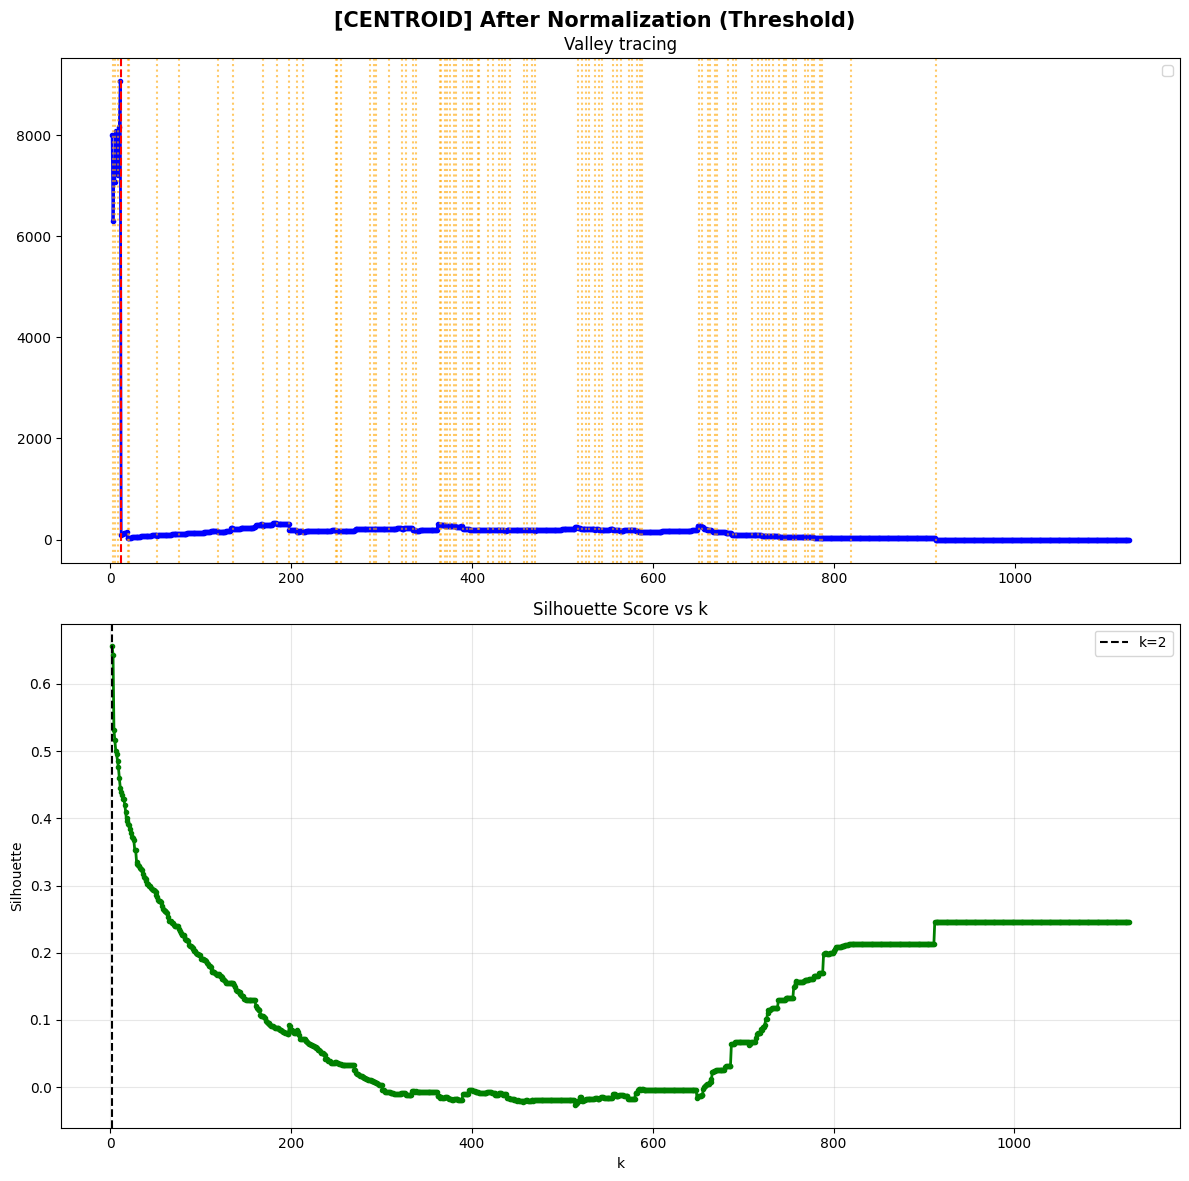

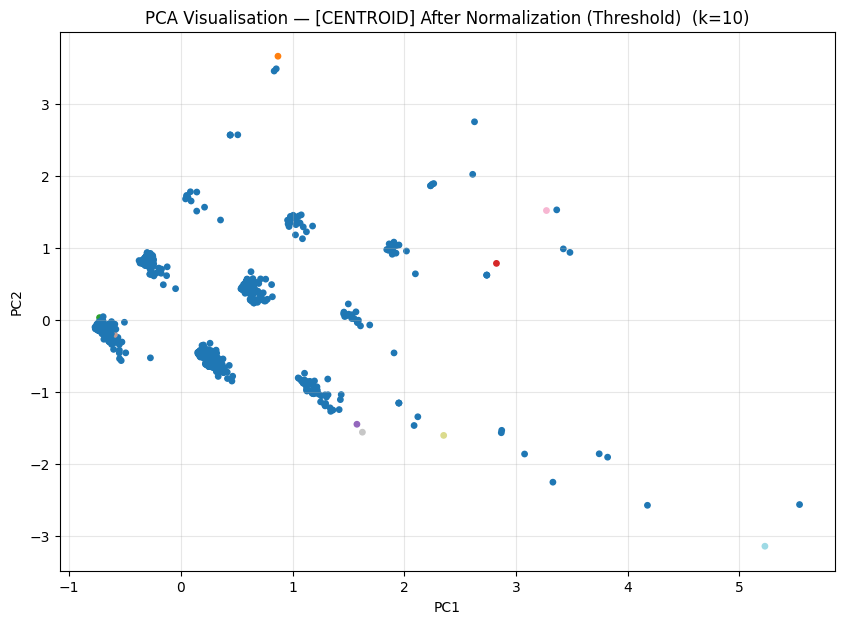

C:\Users\fatim\AppData\Local\Temp\ipykernel_12296\3690677646.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


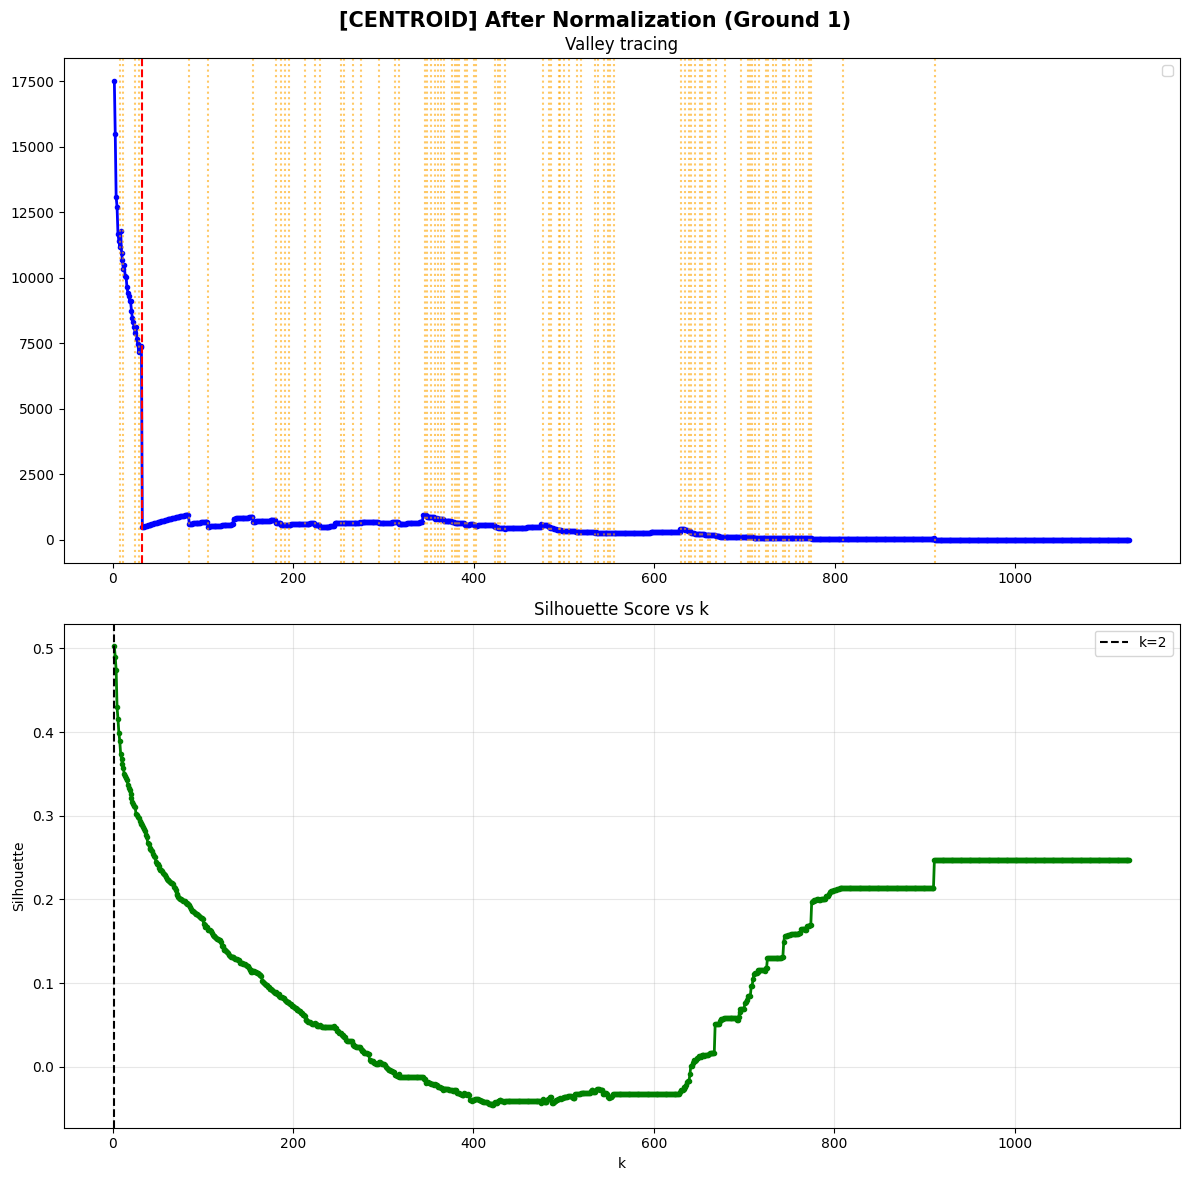

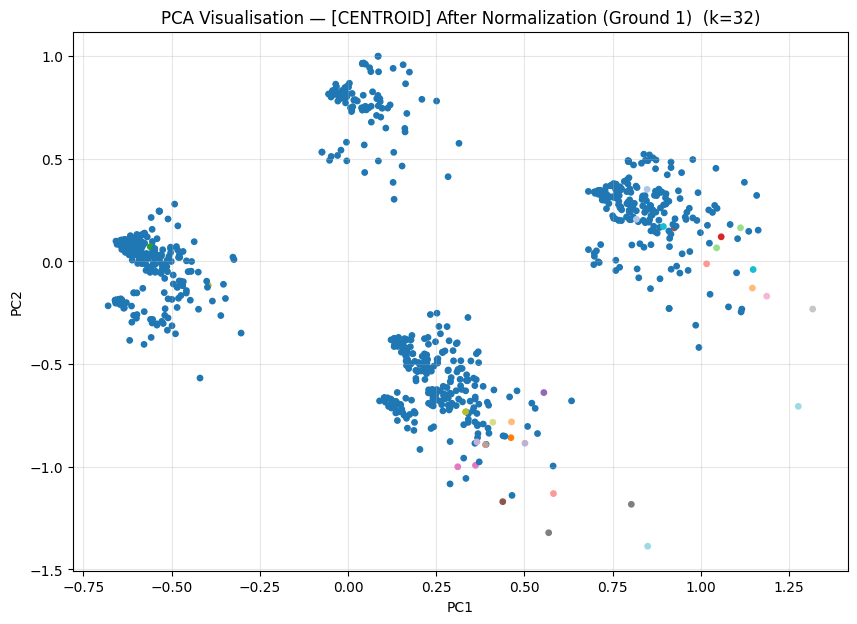

C:\Users\fatim\AppData\Local\Temp\ipykernel_12296\3690677646.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


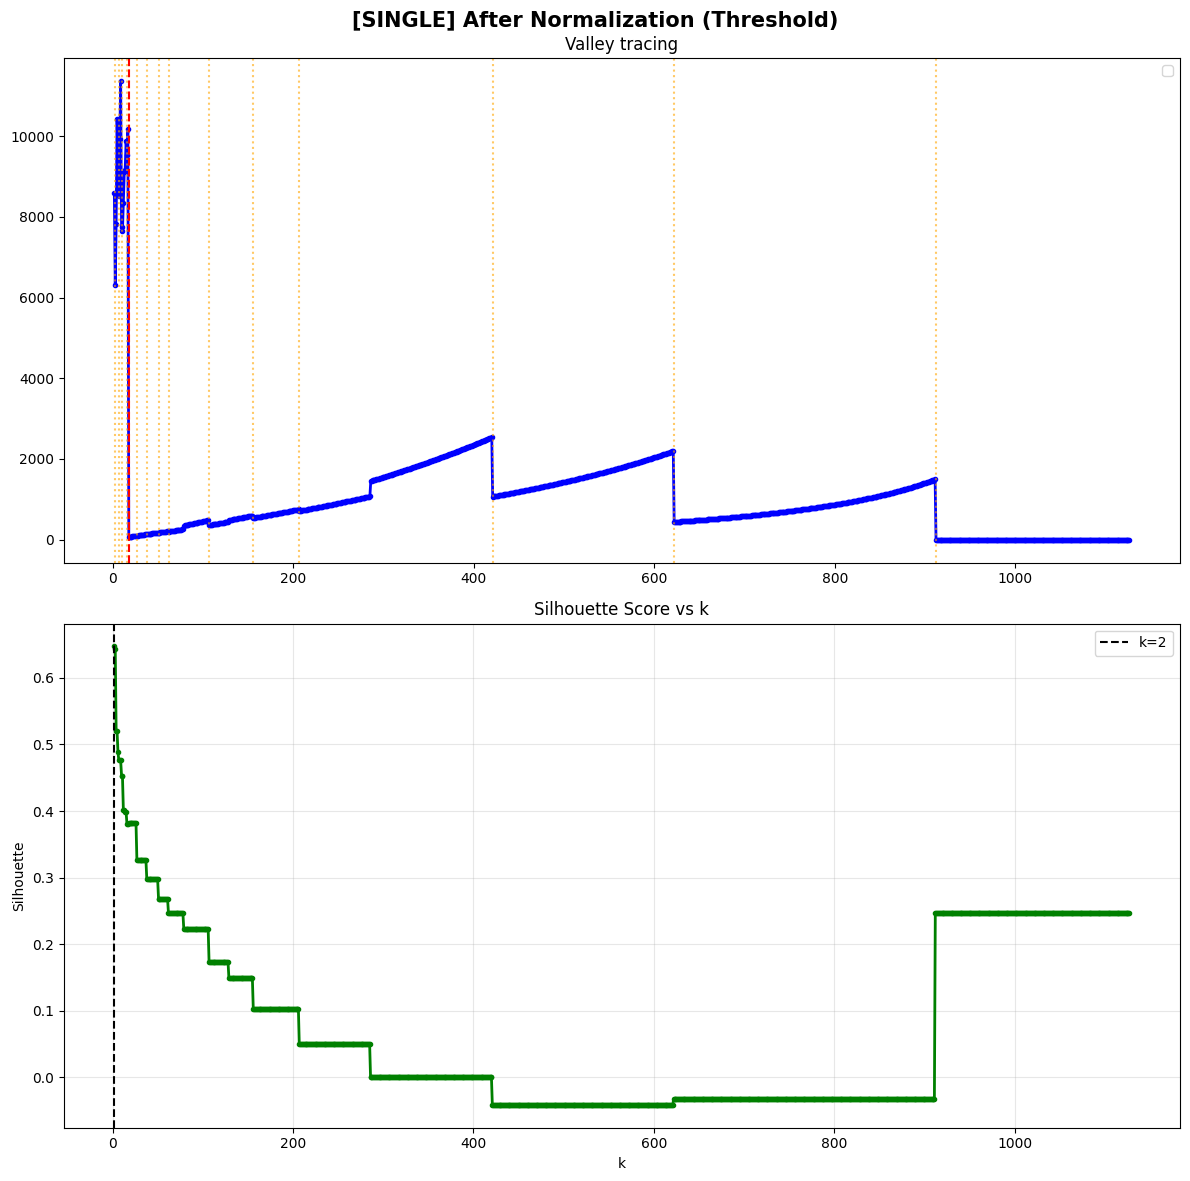

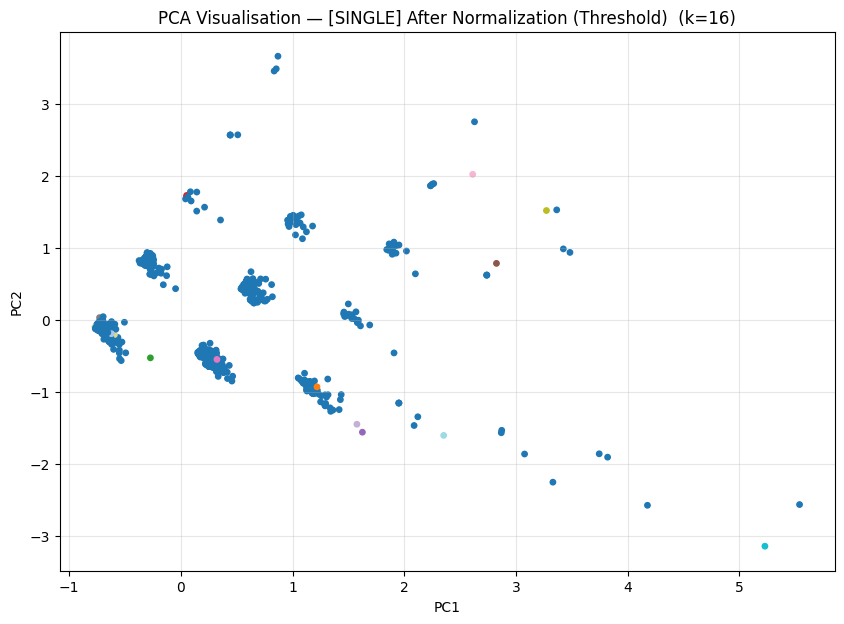

C:\Users\fatim\AppData\Local\Temp\ipykernel_12296\3690677646.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


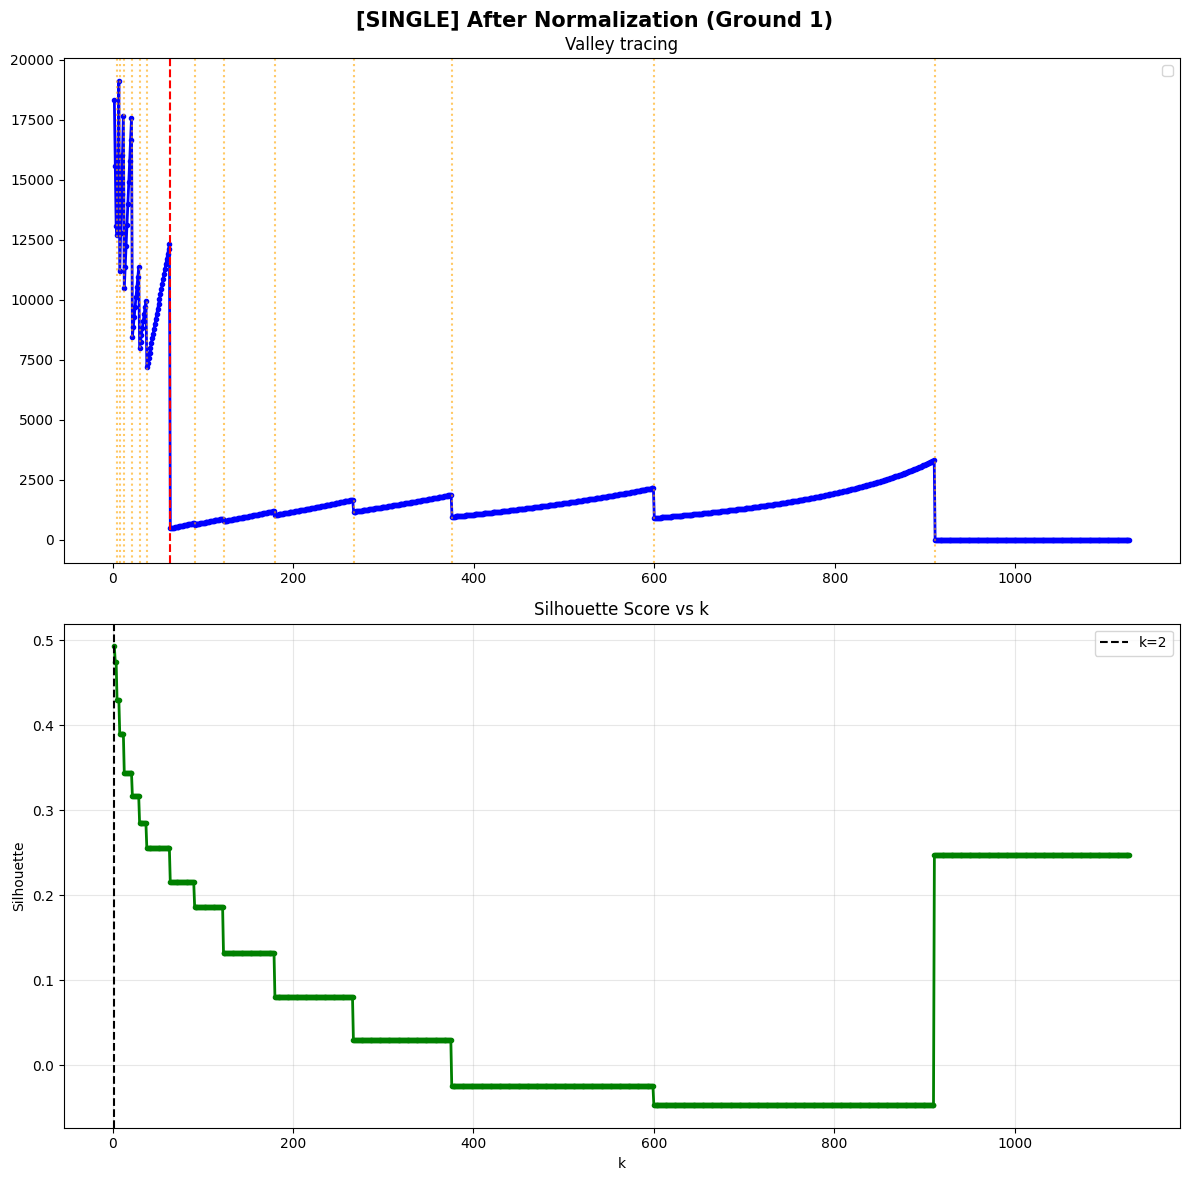

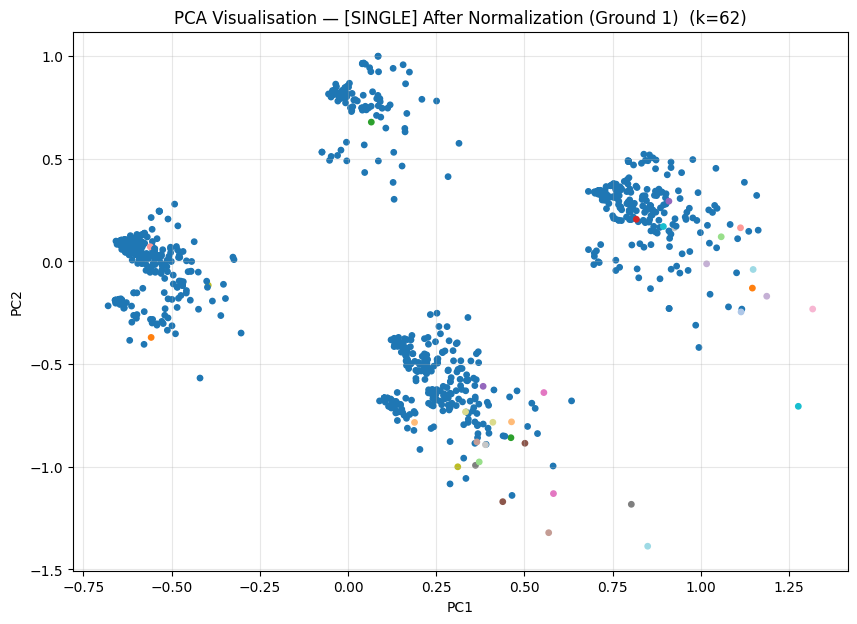

C:\Users\fatim\AppData\Local\Temp\ipykernel_12296\3690677646.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


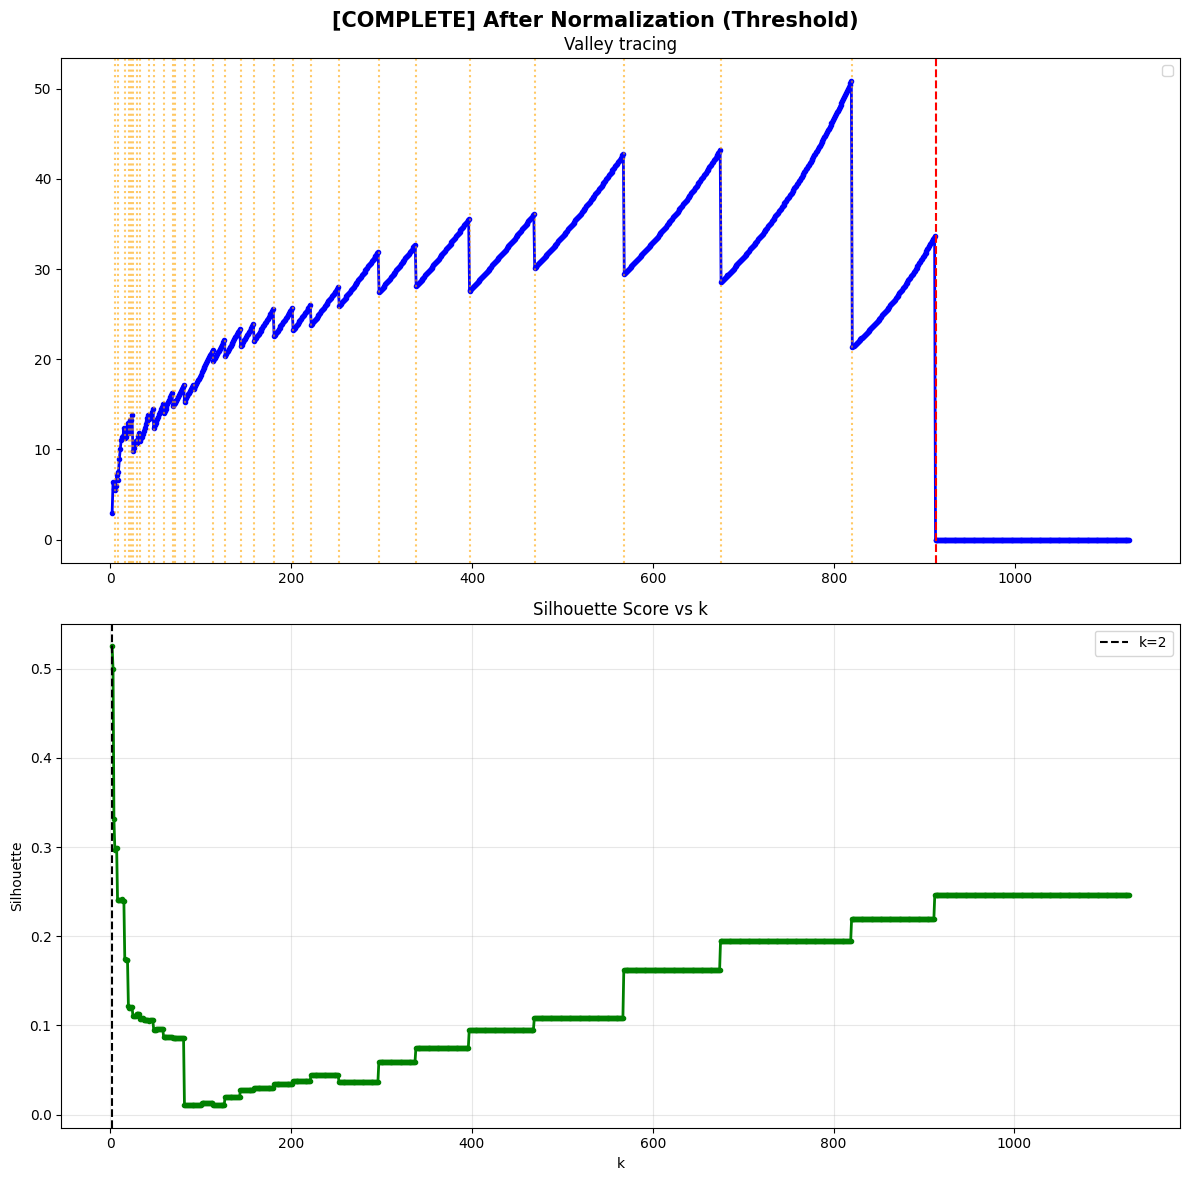

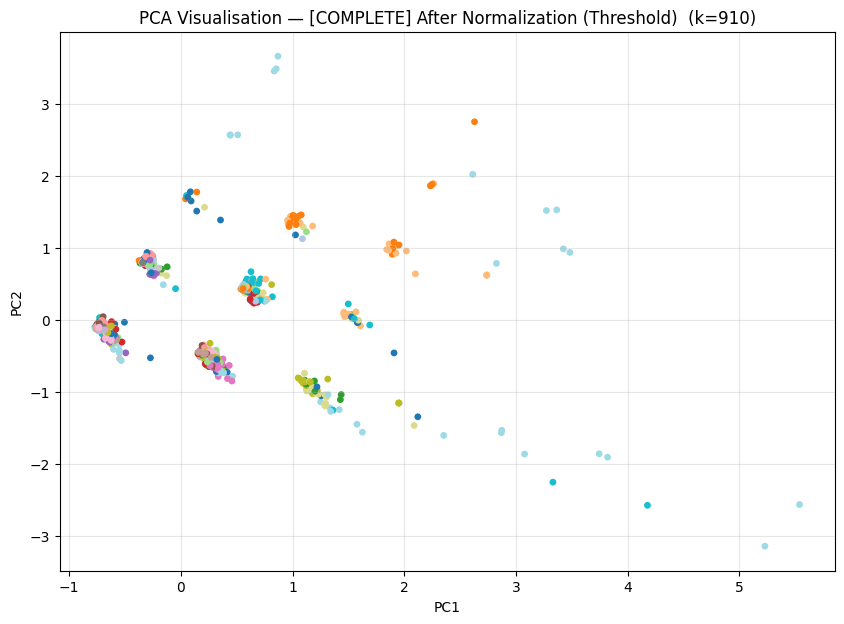

C:\Users\fatim\AppData\Local\Temp\ipykernel_12296\3690677646.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


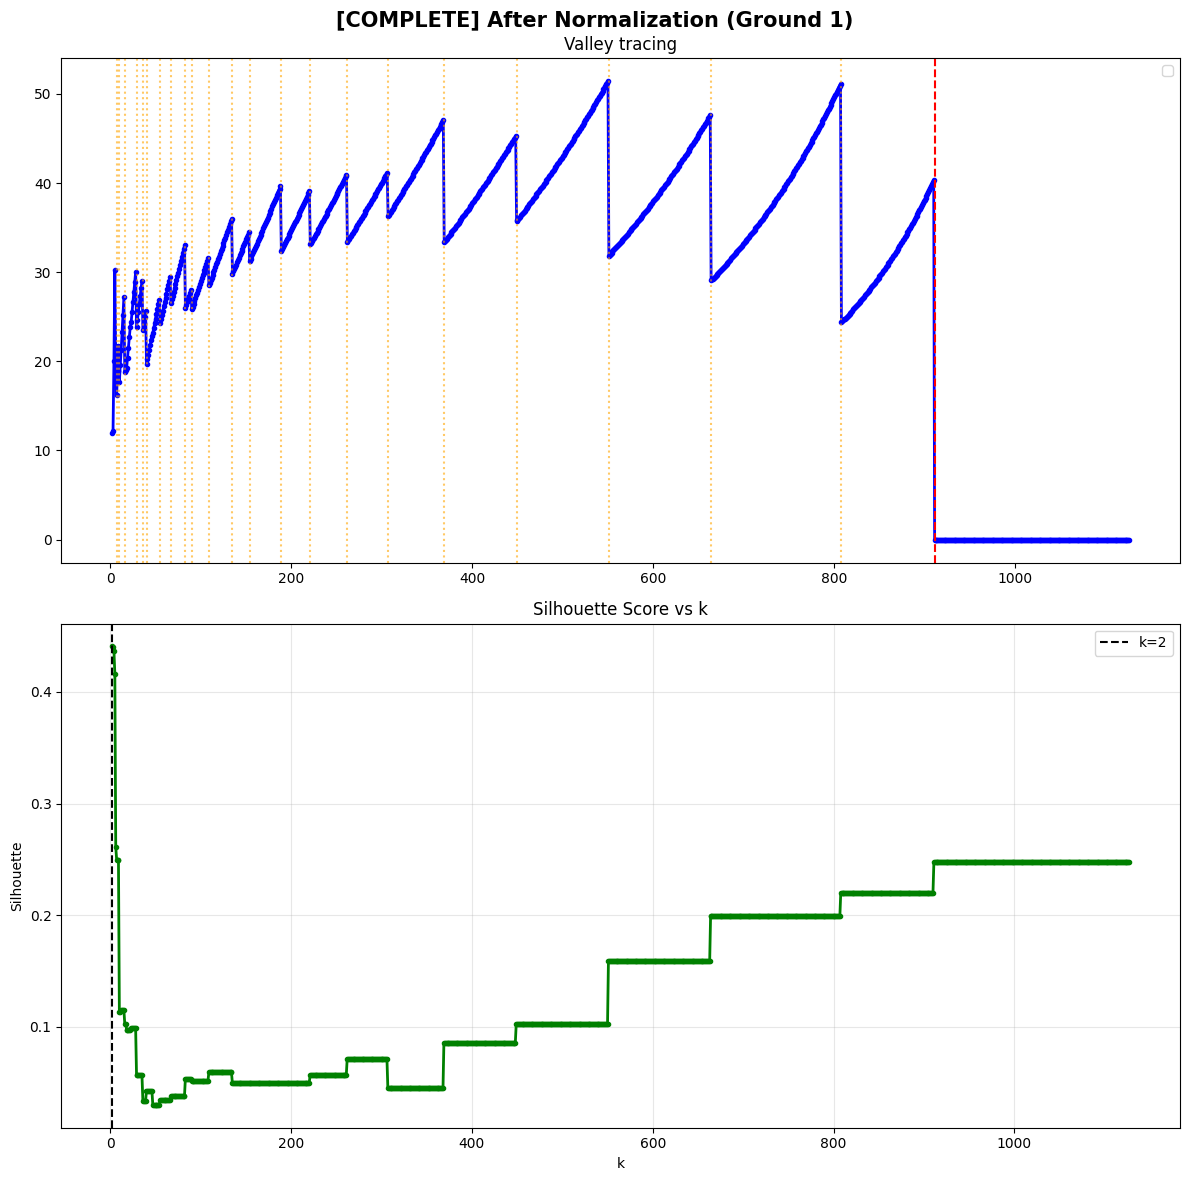

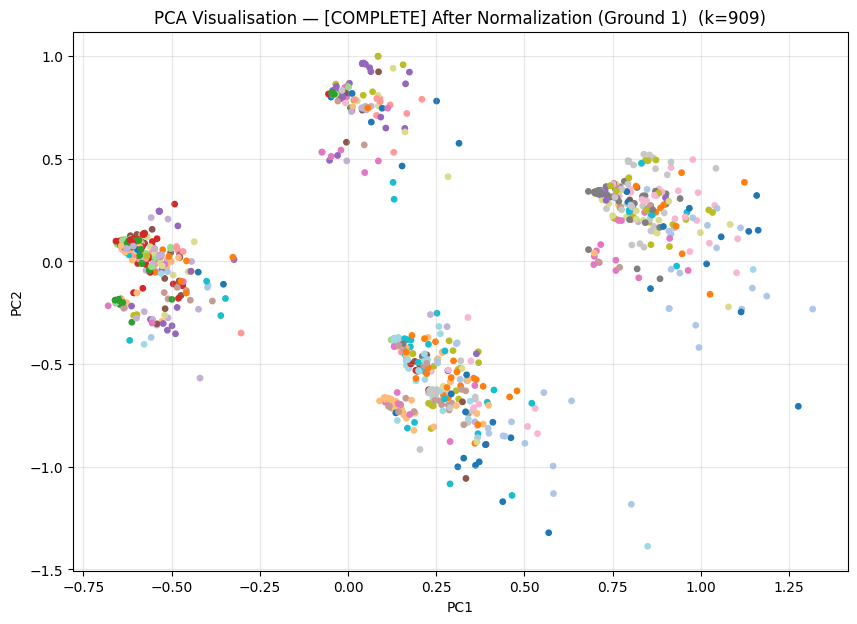

C:\Users\fatim\AppData\Local\Temp\ipykernel_12296\3690677646.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


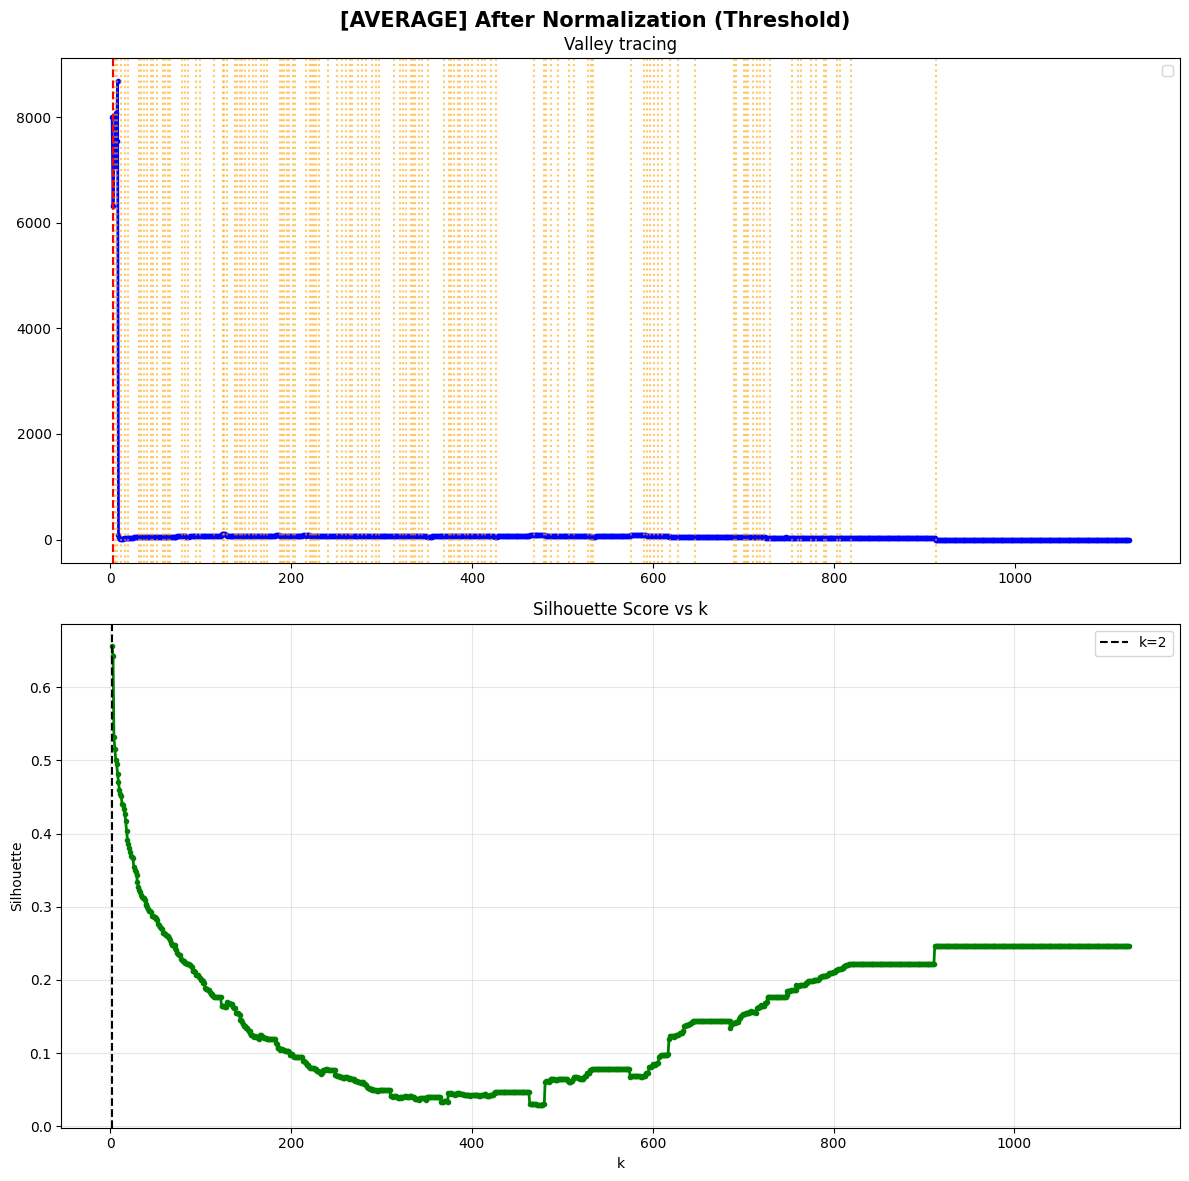

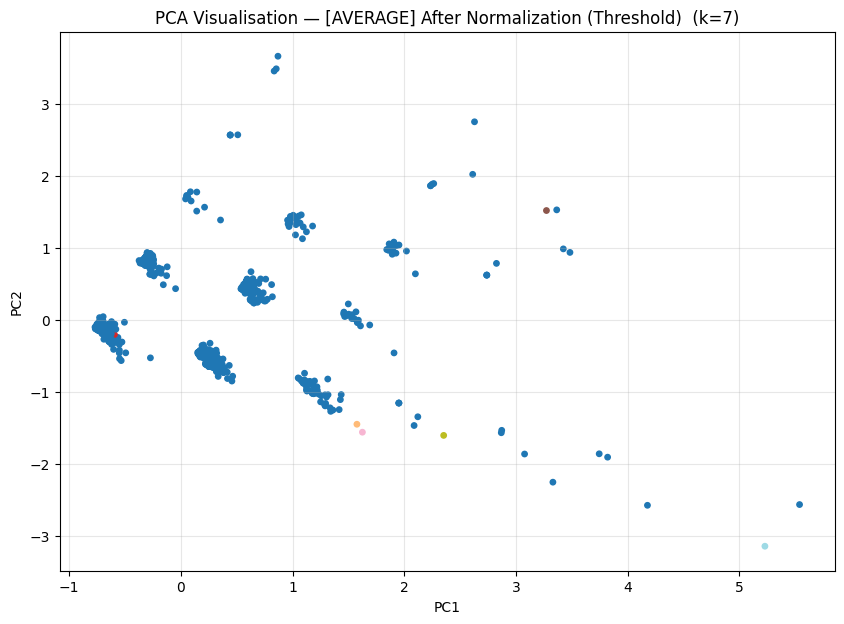

C:\Users\fatim\AppData\Local\Temp\ipykernel_12296\3690677646.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


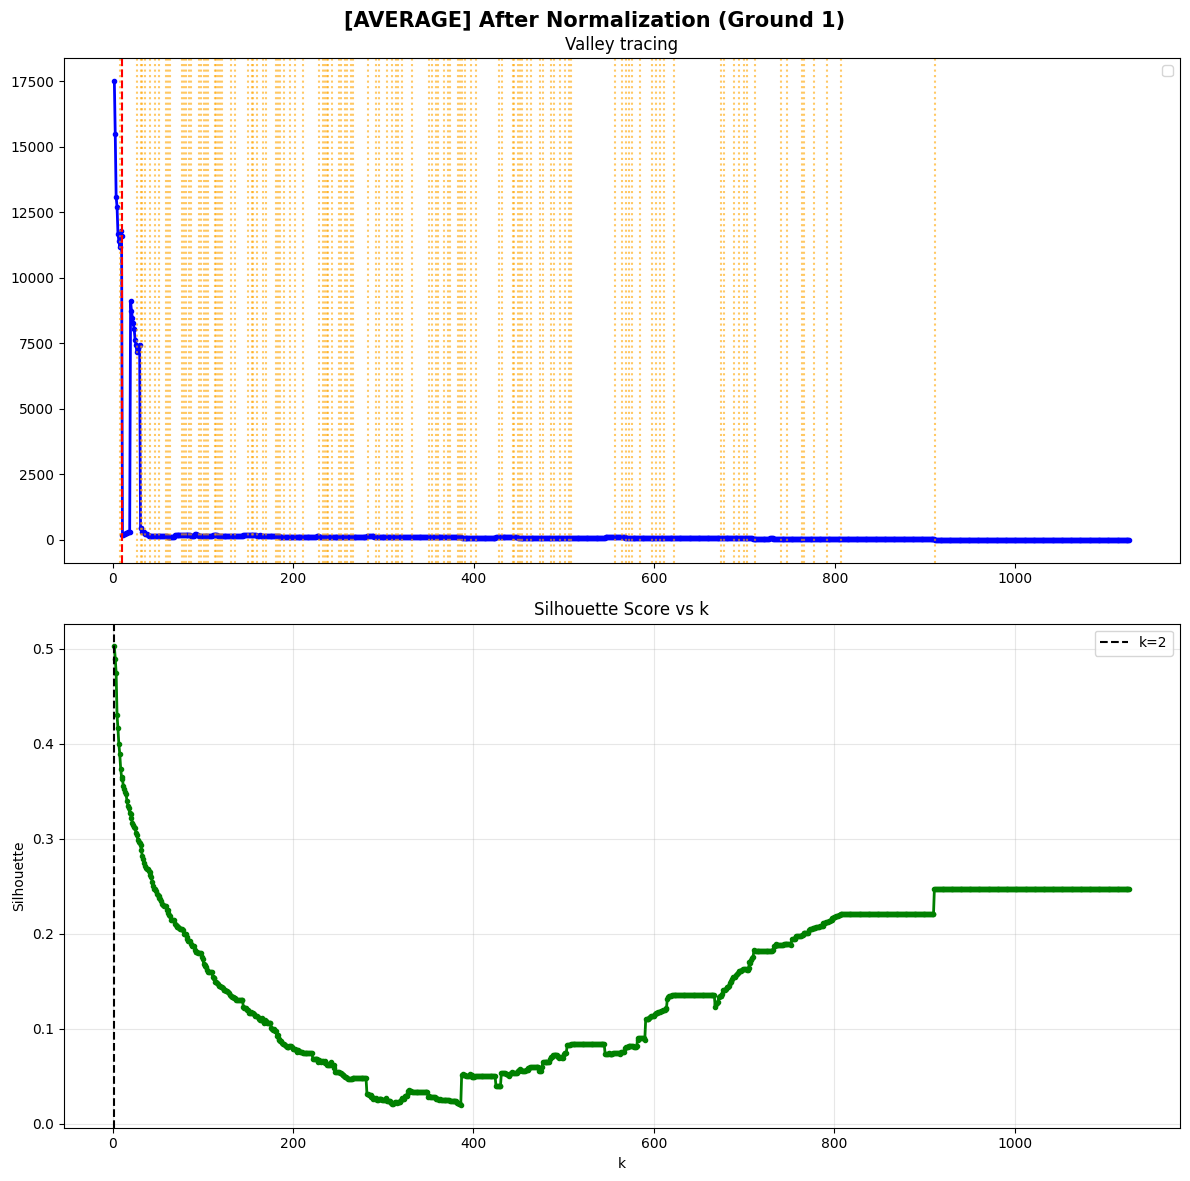

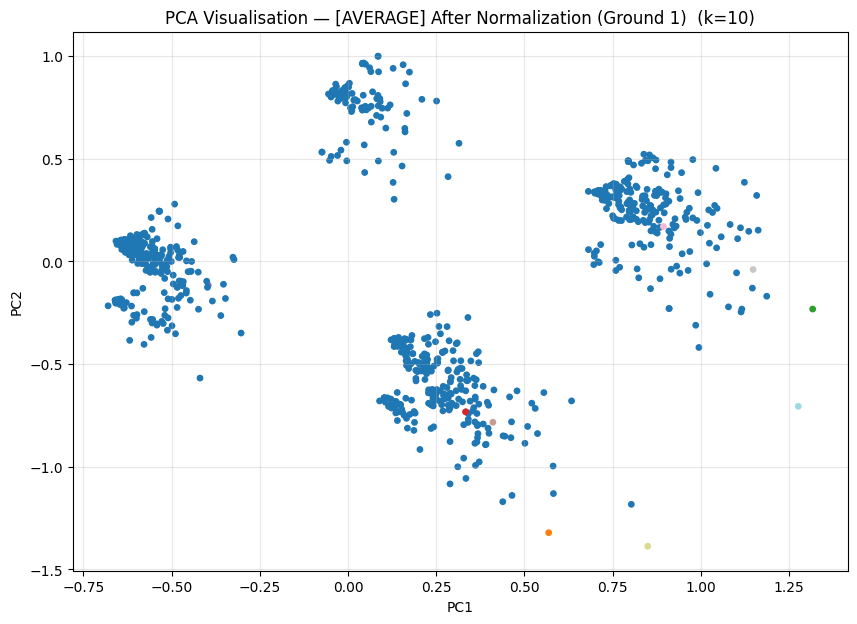

In [15]:
for ver_name, res in v_results.items():
    v_ratio = res['v_ratio']
    sil     = res['sil']
    k_list  = res['k_list']
    k_curv  = res['k_curv']
    k_sil   = res['k_sil']
    Z       = res['Z']
    vec     = res['vec']
    valley_k= res['valley_k']
    best_k  = res['best_k']

    fig, axes = plt.subplots(2, 1, figsize=(12, 12))
    fig.suptitle(ver_name, fontsize=15, fontweight='bold')

    axes[0].plot(k_list, v_ratio, 'bo-', linewidth=2, markersize=3)
    axes[0].set_title("Valley tracing")
    axes[0].legend()
    if valley_k:
        for vk in valley_k:
            axes[0].axvline(vk, color='orange', linestyle=':', alpha=0.6, label=f"valley k={vk}")
        axes[0].axvline(best_k, color='red', linestyle='--', label=f"best k={best_k}")
    # axes[0].legend()

    axes[1].plot(k_list, sil, 'go-', linewidth=2, markersize=3)
    if k_sil:
        axes[1].axvline(k_sil, color='black', linestyle='--', label=f"k={k_sil}")
    axes[1].set_title("Silhouette Score vs k")
    axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
    axes[1].grid(alpha=0.3); axes[1].legend()

    plt.tight_layout()
    plt.show()

    # PCA visualisation at optimal k
    if best_k is not None:
        k_optimal  = k_curv
        labels_opt = fcluster(Z, t=k_optimal, criterion='maxclust')
        pca        = PCA(n_components=2)
        vec2d      = pca.fit_transform(vec)

        plt.figure(figsize=(10, 7))
        plt.scatter(vec2d[:, 0], vec2d[:, 1], c=labels_opt, cmap='tab20', s=15)
        plt.title(f"PCA Visualisation — {ver_name}  (k={k_optimal})")
        plt.xlabel("PC1"); plt.ylabel("PC2")
        plt.grid(alpha=0.3)
        plt.show()

In [17]:
feature_map = {
    "Before Normalization": feature_names,
    "After Normalization (Threshold)": feature_names_scene_1,
    "After Normalization (ground 1)": feature_names_scene_2,
}

def display_culster_details(tfidf_matrix, feature_names, labels, k, ver_name=""):
    print(f"\n{'-'*30}")
    print(f"Cluster Details — {ver_name}  (k={k})")
    
    cluster_info = {}
    
    for cluster_id in range(1, k+1):
        indices = np.where(labels == cluster_id)[0]
        
        if len(indices) == 0:
            continue
        
        cluster_data = tfidf_matrix[indices]
        if hasattr(cluster_data, 'toarray'):
            cluster_data = cluster_data.toarray()
        cluster_mean = cluster_data.mean(axis=0)
        threshold = cluster_mean.max() / 2
        above_threshold = np.where(cluster_mean > threshold)[0]
        sorted_idx = above_threshold[np.argsort(-cluster_mean[above_threshold])]
        keywords = [(feature_names[i], cluster_mean[i]) for i in sorted_idx]
        
        cluster_info[cluster_id] = {
            'members': data_partial['processed_text'].iloc[indices].tolist(),
            'count': len(indices),
            'keywords': keywords
        }
    
    for cluster_id, info in cluster_info.items():
        print(f"\nCluster {cluster_id}  ({info['count']} members)")
        print(f"  Members: {info['members']}")
        kw_str = ", ".join([f"{w}({s:.3f})" for w, s in info['keywords'][:10]])
        print(f"  Keywords: {kw_str if kw_str else '—'}")
    
    return cluster_info


for ver_name, res in v_results.items():
    k_used = res.get('best_k') or res['k_curv']
    k_used = int(k_used)
    labels_opt = fcluster(res['Z'], t=k_used, criterion='maxclust')
    scenario = res['scenario']
    features = feature_map.get(scenario, feature_names)

    display_culster_details(
        tfidf_matrix=res['vec'],
        feature_names=features,
        labels=labels_opt,
        k=k_used,
        ver_name=ver_name
    )


------------------------------
Cluster Details — [CENTROID] After Normalization (Threshold)  (k=12)

Cluster 1  (2 members)
  Members: ['aduh pdam gayungsari barat area resto kampung steak mati nyala air nyala mati nyala rumah mati bagi air bingung tampung air habis bantu pdam', 'aduh pdam gayungsari barat area resto kampung steak bingung tampung air rumah habis mati nyala air nyala mati nyala rumah mati bagi air bantu pdam']
  Keywords: air(3.000), mati(3.000), nyala(3.000), pdam(2.000)

Cluster 2  (1116 members)
  Members: ['paham harga pasang pdam', 'rame', 'pdam jalan gresik mati', 'tugas wilayah ploso timur kali cek air preman ketuk pagar ugal-ugalan kayu pentung preman pagar tetangga', 'kali kirim komplain langsung pecat tugas', 'pdam air hati alir baik', 'kebraon susah aktivitas', 'laku', 'syarat lengkap proses pasang', 'karah mati air pemberitahuan tayamum', 'aju tanggal september keluar rincian tanggal september bayar batas bayar smp oktober harga promo agustus smp september 

Other versions & sehnanigans

In [ ]:
# from sklearn.feature_extraction.text import CountVectorizer
# data_partial['processed_text'] = data_partial['text'].apply(
#     lambda tokens: " ".join(tokens)
# )
# # data_partial['processed_text'] = data_partial['text'].apply(lambda tokens: " ".join(tokens))
# data_partial = data_partial[data_partial['processed_text'].str.strip() != ""]
# vectorizer = CountVectorizer(
#     ngram_range=(1, 1),
#     min_df=0.01,
#     max_df=0.95,
#     tokenizer=str.split
# )
# vectors = vectorizer.fit_transform(data_partial['processed_text'])
# feature_names = vectorizer.get_feature_names_out()
# vectors_dense = vectors.toarray()

d:\Kuliah\PA\pdam-scraper\scrape_instagram\venv\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [ ]:
# PROTECTED_WORDS = [
#     'sememi'
# ]

# factory = StemmerFactory()
# base_stemmer = factory.create_stemmer()

# existing_words = list(base_stemmer.getDictionary().getWords())
# combined_words = list(set(existing_words + PROTECTED_WORDS))
# custom_dict = ArrayDictionary(combined_words)

# stemmer = Stemmer(custom_dict)

# def stem_tokens(tokens):
#     if not isinstance(tokens, list):
#         return tokens
#     return [stemmer.stem(tok) for tok in tokens]

# data_partial["text"] = data_partial["text"].apply(stem_tokens)


AttributeError: 'CachedStemmer' object has no attribute 'getDictionary'

In [ ]:
# min_tokens = 3

# data_filtered = data_partial[data_partial["token_count"] >= min_tokens].copy()
# print(f"Removed {len(data_partial) - len(data_filtered)} short documents")
# print(f"Remaining: {len(data_filtered)} documents")

In [ ]:
# def show_clusters_k(res, k, ver_name, feature_map):
#     print(f"\n{'='*60}")
#     print(f"Showing clusters at k = {k}  |  {ver_name}")
    
#     labels = fcluster(res['Z'], t=k, criterion='maxclust')
    
#     display_culster_details(
#         tfidf_matrix=res['vec'],
#         feature_names=feature_map.get(ver_name, feature_names),
#         labels=labels,
#         k=k,
#         ver_name=f"{ver_name} (k={k})"
#     )
# show_clusters_k(v_results["After Normalization (Threshold)"], 101,
#                    "After Normalization (Threshold)", feature_map)


Showing clusters at k = 101  |  After Normalization (Threshold)

------------------------------
Cluster Details — After Normalization (Threshold) (k=101)  (k=101)

Cluster 1  (2 members)
  Members: ['aduh pdam gayungsari barat area resto kampung steak mati nyala air nyala mati nyala rumah mati bagi air bingung tampung air habis bantu pdam', 'aduh pdam gayungsari barat area resto kampung steak bingung tampung air rumah habis mati nyala air nyala mati nyala rumah mati bagi air bantu pdam']
  Keywords: air(3.000), mati(3.000), nyala(3.000), pdam(2.000)

Cluster 2  (1 members)
  Members: ['merek pipa kualitas seng pakai bocor air mati bayar mahal bolak mati minggu mati cuci seragam yak cak elus karo pikir air tangki solusi pikir kudu kolektif rt pesan air tangki wadah seng tandon coba pikir solusi']
  Keywords: air(3.000), mati(3.000), solusi(2.000)

Cluster 3  (1 members)
  Members: ['malam admin daerah mleto surabaya timur sukolilo september habis subuh siang mati keluar air air lancar 

In [ ]:
# ## WCSS CALCULATION WITH MULTIPLE VECTOR NORMALIZATION SCENARIOS
# import matplotlib.pyplot as plt
# from scipy.cluster.hierarchy import linkage, fcluster
# from sklearn.metrics import silhouette_score
# from sklearn.decomposition import PCA

# VERSIONS = {
#     "Befor Normalization": vectors_dense_old,
#     "After Normalization (Threshold)":  vectors_scene_1,
#     "After Normalization (ground 1)":  vectors_scene_2,
# }
# N = vectors_dense_old.shape[0]-1
# k_list = list(range(N, 1, -1))

# results = {}

# for ver_name, vec in VERSIONS.items():
#     print(f"\n{'='*60}")
#     print(f"Running HAC for: {ver_name}  |  shape: {vec.shape}")
#     print('-'*60)

#     Z = linkage(vec, method='centroid', metric='euclidean')

#     wcss, sil = [], []
#     for k in k_list:
#         labels = fcluster(Z, t=k, criterion='maxclust')

#         # WCSS
#         total_var = 0.0
#         for cid in np.unique(labels):
#             pts = vec[labels == cid]
#             if pts.shape[0] <= 1:
#                 continue
#             cent = pts.mean(axis=0)
#             total_var += np.sum(np.linalg.norm(pts - cent, axis=1) ** 2)
#         wcss.append(total_var)

#         # Sil
#         if len(np.unique(labels)) >= 2:
#             sc = silhouette_score(vec, labels, metric='euclidean')
#         else:
#             sc = np.nan
#         sil.append(sc)

#     wcss = np.array(wcss)
#     sil  = np.array(sil)

#     first  = np.diff(wcss)
#     second = np.diff(first)
#     idx_curv = np.nanargmax(np.abs(second))
#     k_curv = k_list[idx_curv + 2]

#     valid_idx = np.where(~np.isnan(sil))[0]
#     k_sil = k_list[valid_idx[np.nanargmax(sil[valid_idx])]] if len(valid_idx) else None

#     print(f"Optimal K — WCSS Curvature: {k_curv}  |  Silhouette Max: {k_sil}")
#     results[ver_name] = {
#         'Z': Z, 'vec': vec, 'wcss': wcss, 'sil': sil,
#         'k_curv': k_curv, 'k_sil': k_sil
#     }

# for ver_name, res in results.items():
#     wcss   = res['wcss']
#     sil    = res['sil']
#     k_curv = res['k_curv']
#     k_sil  = res['k_sil']
#     Z      = res['Z']
#     vec    = res['vec']
#     second = np.diff(np.diff(wcss))

#     fig, axes = plt.subplots(3, 1, figsize=(12, 18))
#     fig.suptitle(ver_name, fontsize=15, fontweight='bold')

#     axes[0].plot(k_list, wcss, 'bo-', linewidth=1.5, markersize=3)
#     axes[0].axvline(k_curv, color='red', linestyle='--', label=f"k={k_curv}")
#     axes[0].set_title("WCSS vs Number of Clusters")
#     axes[0].set_xlabel("k"); axes[0].set_ylabel("WCSS")
#     axes[0].grid(alpha=0.3); axes[0].legend()

#     axes[1].plot(k_list[2:], np.abs(second), 'ro-', linewidth=1.5, markersize=3)
#     axes[1].axvline(k_curv, color='blue', linestyle='--', label=f"k={k_curv}")
#     axes[1].set_title("WCSS Curvature (Second Derivative)")
#     axes[1].set_xlabel("k"); axes[1].set_ylabel("|d²(WCSS)/dk²|")
#     axes[1].grid(alpha=0.3); axes[1].legend()

#     axes[2].plot(k_list, sil, 'go-', linewidth=1.5, markersize=3)
#     if k_sil:
#         axes[2].axvline(k_sil, color='black', linestyle='--', label=f"k={k_sil}")
#     axes[2].set_title("Silhouette Score vs k")
#     axes[2].set_xlabel("k"); axes[2].set_ylabel("Silhouette")
#     axes[2].grid(alpha=0.3); axes[2].legend()

#     plt.tight_layout()
#     plt.show()

#     k_optimal = k_curv
#     labels_opt = fcluster(Z, t=k_optimal, criterion='maxclust')
#     pca  = PCA(n_components=2)
#     vec2d = pca.fit_transform(vec)

#     plt.figure(figsize=(10, 7))
#     plt.scatter(vec2d[:, 0], vec2d[:, 1], c=labels_opt, cmap='tab20', s=15)
#     plt.title(f"PCA Visualisation — {ver_name}  (k={k_optimal})")
#     plt.xlabel("PC1"); plt.ylabel("PC2")
#     plt.grid(alpha=0.3)
#     plt.show()


Running HAC for: Befor Normalization  |  shape: (1133, 114)
------------------------------------------------------------


KeyboardInterrupt: 

In [ ]:
# feature_map = {
#     "Before Normalization": feature_names,
#     "After Normalization (Threshold)": feature_names_scene_1,
#     "After Normalization (ground 1)": feature_names_scene_2,
# }

# def display_culster_details(tfidf_matrix, feature_names, labels, k, ver_name=""):
#     print(f"\n{'-'*30}")
#     print(f"Cluster Details — {ver_name}  (k={k})")
    
#     cluster_info = {}
    
#     for cluster_id in range(0, k):
#         indices = np.where(labels == cluster_id)[0]
        
#         if len(indices) == 0:
#             continue
        
#         cluster_data = tfidf_matrix[indices]
#         if hasattr(cluster_data, 'toarray'):
#             cluster_data = cluster_data.toarray()
#         cluster_mean = cluster_data.mean(axis=0)
#         threshold = cluster_mean.max() / 2
#         above_threshold = np.where(cluster_mean > threshold)[0]
#         sorted_idx = above_threshold[np.argsort(-cluster_mean[above_threshold])]
#         keywords = [(feature_names[i], cluster_mean[i]) for i in sorted_idx]
        
#         cluster_info[cluster_id] = {
#             'members': data_partial['processed_text'].iloc[indices].tolist(),
#             'count': len(indices),
#             'keywords': keywords
#         }
    
#     for cluster_id, info in cluster_info.items():
#         print(f"\nCluster {cluster_id}  ({info['count']} members)")
#         print(f"  Members: {info['members']}")
#         kw_str = ", ".join([f"{w}({s:.3f})" for w, s in info['keywords'][:10]])
#         print(f"  Keywords: {kw_str if kw_str else '—'}")
    
#     return cluster_info


# for ver_name, res in results.items():
#     labels_opt = fcluster(res['Z'], t=res['k_curv'], criterion='maxclust')
#     display_culster_details(
#         tfidf_matrix=res['vec'],
#         feature_names=feature_map.get(ver_name, feature_names),
#         labels=labels_opt,
#         k=res['k_curv'],
#         ver_name=ver_name
#     )


------------------------------
Cluster Details — Befor Normalization  (k=2)

Cluster 1  (1151 members)
  Members: ['maaf paham harga pasang pdam', 'rame nih', 'pdam jalan gresik mati', 'tugas wilayah ploso timur tolong kali cek air preman ketuk pagar ugal-ugalan kayu pentung preman pagar tetangga', 'kali kirim komplain langsung pecat tugas', 'terima kasih', 'pdam air hati alir tolong baik', 'kebraon susah aktivitas', 'laku', 'syarat lengkap proses pasang', 'karah mati air jam pemberitahuan tayamum', 'aju tanggal september keluar rincian tanggal september bayar batas bayar smp oktober harga promo agustus smp september promo', 'dm ya kak', 'rungkut industri air mati', 'pdam air keruh', 'kertaja kecil air', 'karang menjangan susah air bos', 'tagih pdam lonjak drastis', 'pdam wonorejo rungkut mati', 'adu gubris ya cs aja tugas air mati hari krn meter bocor habis ganti meter masalah', 'info ganggu air wilayah babat jerawat pondok benowo indah', 'lapor pdam gara-gara air jumat jam jam malam


Running V-Ratio for: After Normalization (Threshold)  |  shape: (1151, 144)
------------------------------------------------------------
Optimal K — V-Ratio Curvature: 4  |  Silhouette Max: 2
Valley-tracing candidate k values: [933, 823, 806, 800, 785, 783, 778, 764, 760, 755, 748, 737, 731, 726, 721, 688, 685, 682, 680, 677, 673, 660, 657, 653, 647, 645, 641, 581, 577, 573, 568, 566, 563, 557, 554, 551, 543, 541, 530, 528, 524, 522, 515, 512, 510, 508, 460, 454, 452, 449, 447, 443, 434, 429, 426, 422, 417, 410, 402, 398, 395, 389, 386, 384, 378, 376, 328, 310, 302, 299, 296, 294, 290, 285, 277, 259, 241, 228, 202, 200, 191, 181, 141, 89, 80, 78, 70, 56, 46, 42, 34, 16, 6, 4]
Best k by valley-tracing: 933

Running V-Ratio for: After Normalization (Ground 1)  |  shape: (1151, 144)
------------------------------------------------------------
Optimal K — V-Ratio Curvature: 23  |  Silhouette Max: 2
Valley-tracing candidate k values: [925, 810, 792, 787, 785, 781, 775, 769, 764, 762, 759, 

C:\Users\fatim\AppData\Local\Temp\ipykernel_9688\2094528510.py:123: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


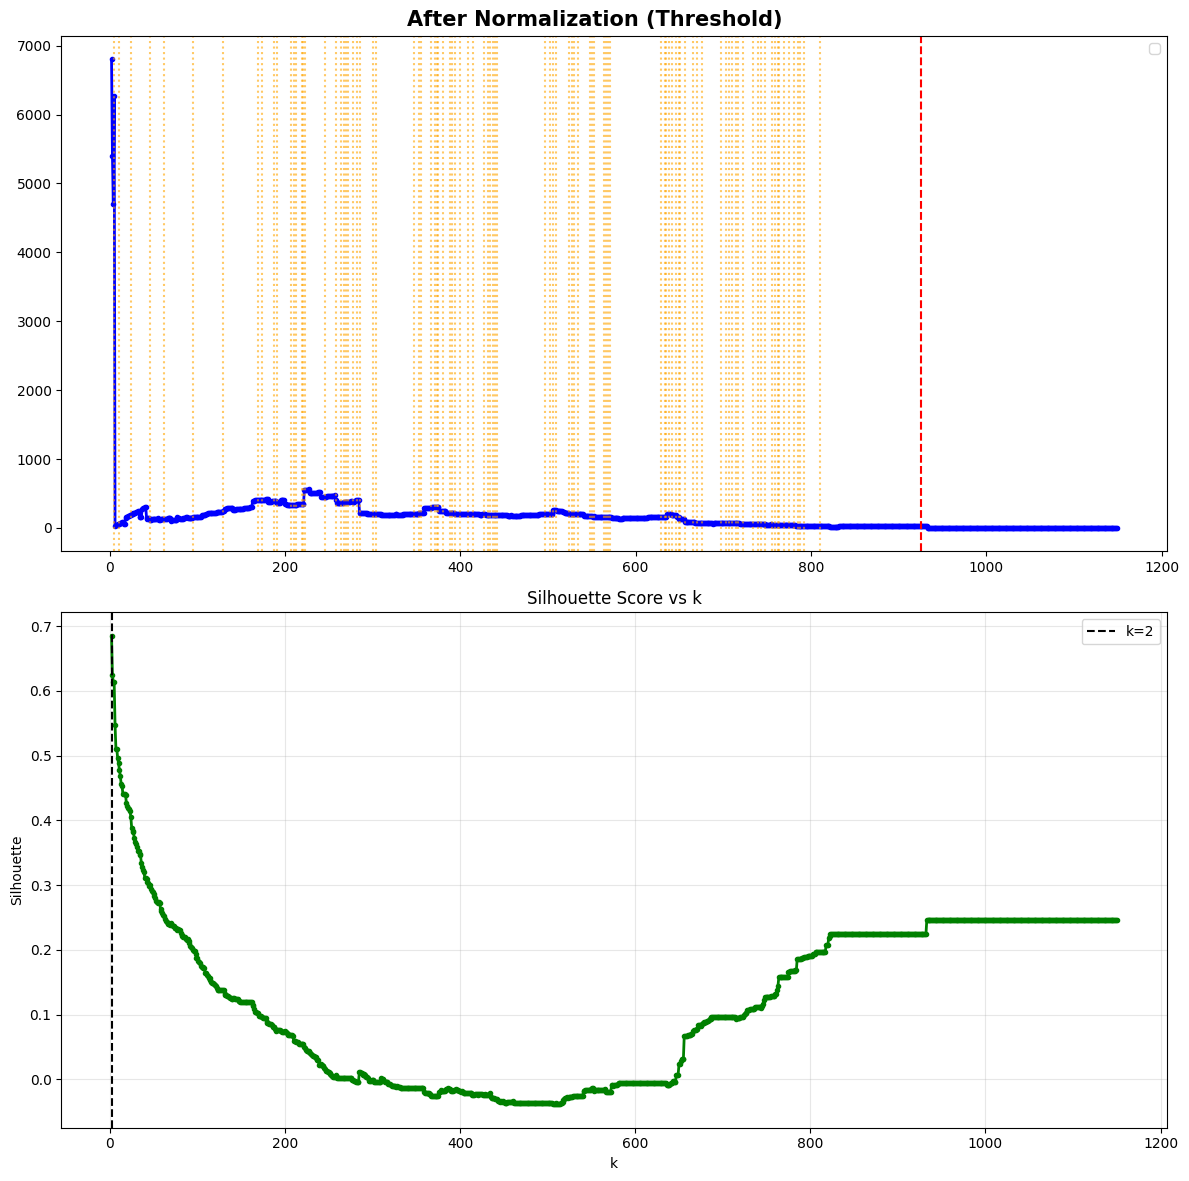

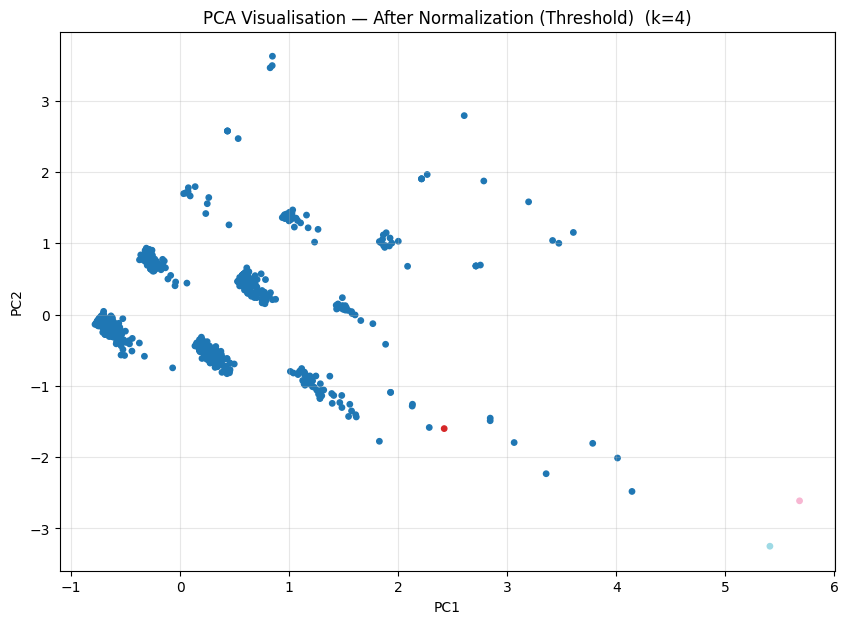

C:\Users\fatim\AppData\Local\Temp\ipykernel_9688\2094528510.py:123: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


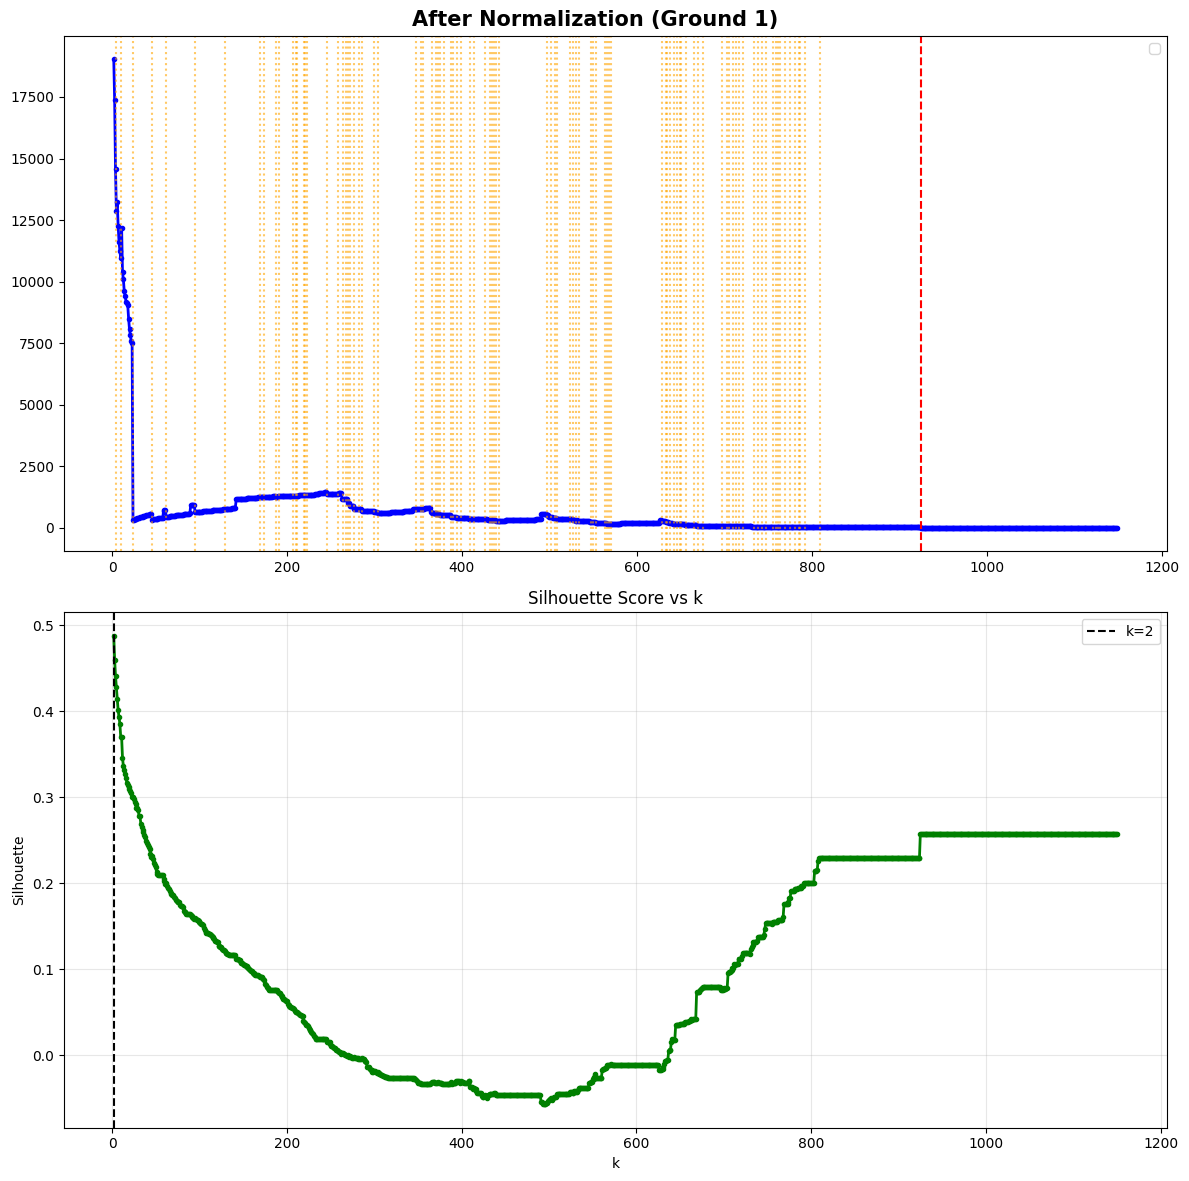

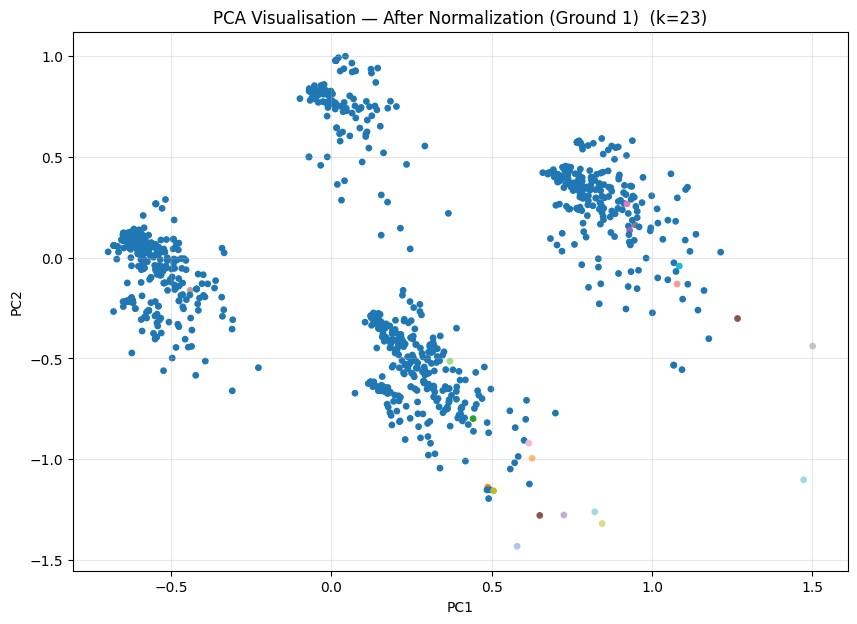

In [ ]:
# ## V RATIO CALCULATION WITH MULTIPLE VECTOR NORMALIZATION SCENARIOS
# import matplotlib.pyplot as plt
# from scipy.cluster.hierarchy import linkage, fcluster
# from sklearn.metrics import silhouette_score
# from sklearn.decomposition import PCA

# VERSIONS = {
#     # "Before Normalization":              vectors_dense_old,
#     "After Normalization (Threshold)":   vectors_scene_1,
#     "After Normalization (Ground 1)":    vectors_scene_2,
# }

# v_results = {}

# for ver_name, vec in VERSIONS.items():
#     print(f"\n{'='*60}")
#     print(f"Running V-Ratio for: {ver_name}  |  shape: {vec.shape}")
#     print('-'*60)

#     N = vec.shape[0] - 1
#     Z = linkage(vec, method='centroid', metric='euclidean')
#     k_list = list(range(N, 1, -1))

#     grand_mean = vec.mean(axis=0)

#     sil       = []
#     vw_list   = []
#     vb_list   = []
#     v_ratio   = []
#     valley_k = []


#     for k in k_list:
#         labels          = fcluster(Z, t=k, criterion='maxclust')
#         unique_clusters = np.unique(labels)

#         delta_within  = 0.0
#         delta_between = 0.0

#         for cid in unique_clusters:
#             pts = vec[labels == cid]
#             ni  = pts.shape[0]
#             if ni <= 1:
#                 continue

#             centroid  = pts.mean(axis=0)
#             delta_sq  = np.sum(np.linalg.norm(pts - centroid, axis=1) ** 2) / (ni - 1)
#             delta_within  += (ni - 1) * delta_sq
#             delta_between += ni * np.linalg.norm(centroid - grand_mean) ** 2

#         vw2 = delta_within  / (N - k) if (N - k) > 0 else np.nan
#         vb2 = delta_between / (k - 1) if (k - 1) > 0 else np.nan

#         vw_list.append(vw2)
#         vb_list.append(vb2)
#         v_ratio.append((vw2 / vb2) * 100 if (vb2 and vb2 > 0) else np.nan)

#         sc = (silhouette_score(vec, labels, metric='euclidean')
#               if len(unique_clusters) >= 2 else np.nan)
#         sil.append(sc)

#     vw_list = np.array(vw_list)
#     vb_list = np.array(vb_list)
#     v_ratio = np.array(v_ratio)
#     sil     = np.array(sil)

#     # Optimal k via curvature of V-Ratio
#     first      = np.diff(v_ratio)
#     second     = np.diff(first)
#     idx_curv   = np.nanargmax(np.abs(second))
#     k_curv     = k_list[idx_curv + 2]

#     # Optimal k via Silhouette
#     valid_idx = np.where(~np.isnan(sil))[0]
#     k_sil     = k_list[valid_idx[np.nanargmax(sil[valid_idx])]] if len(valid_idx) else None

#     print(f"Optimal K — V-Ratio Curvature: {k_curv}  |  Silhouette Max: {k_sil}")


#     for i in range(1, len(v_ratio) - 1):
#         prev = v_ratio[i - 1]
#         curr = v_ratio[i]
#         nxt  = v_ratio[i + 1]
        
#         # skip if any are nan
#         if np.isnan(prev) or np.isnan(curr) or np.isnan(nxt):
#             continue
        
#         # paper eq (7): (V_{i-1} >= V_i) ∩ (V_{i+1} > V_i)
#         if prev >= curr and nxt > curr:
#             valley_k.append(k_list[i])

#     print("Valley-tracing candidate k values:", valley_k)

#     # global optimum is the valley with the lowest v_ratio value 4now
#     # sld probs reconfirm
#     if valley_k:
#         best_k = min(valley_k, key=lambda k: v_ratio[k_list.index(k)])
#         print(f"Best k by valley-tracing: {best_k}")
#     v_results[ver_name] = {
#         'Z': Z, 'vec': vec, 'k_list': k_list,
#         'v_ratio': v_ratio, 'sil': sil,
#         'k_curv': k_curv, 'k_sil': k_sil,
#         'valley_k': valley_k
#     }

# for ver_name, res in v_results.items():
#     v_ratio = res['v_ratio']
#     sil     = res['sil']
#     k_list  = res['k_list']
#     k_curv  = res['k_curv']
#     k_sil   = res['k_sil']
#     Z       = res['Z']
#     vec     = res['vec']

#     fig, axes = plt.subplots(2, 1, figsize=(12, 12))
#     fig.suptitle(ver_name, fontsize=15, fontweight='bold')

#     axes[0].plot(k_list, v_ratio, 'bo-', linewidth=2, markersize=3)
#     # axes[0].axvline(k_curv, color='red', linestyle='--', label=f"k={k_curv}")
#     # axes[0].set_title("V-Ratio (vw²/vb²) vs k")
#     # axes[0].set_xlabel("k"); axes[0].set_ylabel("V (%)")
#     # axes[0].grid(alpha=0.3); 
#     axes[0].legend()
#     if valley_k:
#         for vk in valley_k:
#             axes[0].axvline(vk, color='orange', linestyle=':', alpha=0.6, label=f"valley k={vk}")
#         axes[0].axvline(best_k, color='red', linestyle='--', label=f"best k={best_k}")
#     # axes[0].legend()

#     axes[1].plot(k_list, sil, 'go-', linewidth=2, markersize=3)
#     if k_sil:
#         axes[1].axvline(k_sil, color='black', linestyle='--', label=f"k={k_sil}")
#     axes[1].set_title("Silhouette Score vs k")
#     axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
#     axes[1].grid(alpha=0.3); axes[1].legend()

#     plt.tight_layout()
#     plt.show()

#     # PCA visualisation at optimal k
#     k_optimal  = k_curv
#     labels_opt = fcluster(Z, t=k_optimal, criterion='maxclust')
#     pca        = PCA(n_components=2)
#     vec2d      = pca.fit_transform(vec)

#     plt.figure(figsize=(10, 7))
#     plt.scatter(vec2d[:, 0], vec2d[:, 1], c=labels_opt, cmap='tab20', s=15)
#     plt.title(f"PCA Visualisation — {ver_name}  (k={k_optimal})")
#     plt.xlabel("PC1"); plt.ylabel("PC2")
#     plt.grid(alpha=0.3)
#     plt.show()

visualisation

In [ ]:
# def simple_keyword(tfidf_matrix, feature_names, labels, k):
#     cluster_keywords = {}
    
#     for cluster_id in range(1, k + 1):
#         indices = np.where(labels == cluster_id)[0]
        
#         if len(indices) == 0:
#             cluster_keywords[cluster_id] = []
#             continue

#         cluster_data = tfidf_matrix[indices]

#         if hasattr(cluster_data, 'toarray'):
#             cluster_data = cluster_data.toarray()

#         cluster_mean = cluster_data.mean(axis=0)
#         threshold = cluster_mean.max() / 2
#         above_threshold = np.where(cluster_mean > threshold)[0]
#         sorted_idx = above_threshold[np.argsort(-cluster_mean[above_threshold])]
        
#         keywords = [(feature_names[i], cluster_mean[i]) for i in sorted_idx]
#         cluster_keywords[cluster_id] = keywords
    
#     return cluster_keywords

# keywords = simple_keyword(vectors_dense, feature_names, labels_opt, k_optimal)

# for cluster_id in range(1, min(k_optimal + 1, N)):
#     if cluster_id in keywords and keywords[cluster_id]:
#         print(f"\nCluster {cluster_id}:")
#         for word, score in keywords[cluster_id][:10]:
#             print(f"  {word}: {score:.3f}")


Cluster 1:
  air: 0.114
  mati: 0.109
  min: 0.084
  nyala: 0.067

Cluster 2:
  dampak: 0.560
  warga: 0.541
  baik: 0.452
  ga: 0.435

Cluster 3:
  daerah: 0.612
  moga: 0.421
  kali: 0.413
  surabaya: 0.387
  num: 0.357

Cluster 4:
  pasang: 0.586
  pipa: 0.507
  selesai: 0.470
  kebraon: 0.424

Cluster 5:
  cuci: 0.533
  gin: 0.496
  aja: 0.469
  malam: 0.382
  jam: 0.322

Cluster 6:
  mem: 0.678
  sek: 0.498
  kemarin: 0.400
  alir: 0.364

Cluster 7:
  orang: 0.601
  benowo: 0.521
  rumah: 0.454
  gak: 0.402

Cluster 8:
  selamat: 0.456
  jalan: 0.436
  bocor: 0.416
  pipa: 0.403
  num: 0.387
  malam: 0.342

Cluster 9:
  admin: 0.541
  minggu: 0.524
  mandi: 0.482
  tolong: 0.448

Cluster 10:
  respon: 0.572
  area: 0.536
  admin: 0.510
  air: 0.354

Cluster 11:
  e: 0.582
  ga: 0.467
  pasang: 0.392
  cek: 0.384
  opo: 0.377

Cluster 12:
  pakal: 0.563
  sore: 0.511
  benowo: 0.494
  alir: 0.422

Cluster 13:
  cepat: 0.509
  butuh: 0.485
  warga: 0.447
  selesai: 0.409
  tolong: 

In [ ]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# data_filtered['processed_text'] = data_partial['text'].apply(
#     lambda tokens: " ".join(tokens)
# )
# data_filtered = data_filtered[data_filtered['processed_text'].str.strip() != ""]
# vectorizer = TfidfVectorizer(
#     tokenizer=str.split,
#     ngram_range=(1,1),
#     min_df=5,
#     max_df=0.95,
#     use_idf=False,
#     norm=None
# )

# vectors = vectorizer.fit_transform(data_filtered['processed_text'])
# feature_names = vectorizer.get_feature_names_out()
# vectors_dense = vectors.toarray()

# print(f"Vector shape: {vectors.shape}")
# print(f"nonzero: {vectors.nnz}")
# row = vectors[1]
# indices = row.indices
# values = row.data

# for i, v in zip(indices, values):
#     print(feature_names[i], v) 


# vectors = vectorizer.fit_transform(data_filtered['processed_text'])
# feature_names = vectorizer.get_feature_names_out()
# vectors_dense = vectors.toarray()

# vectors_dense_old = vectors_dense.copy()
# df_old = pd.DataFrame(vectors_dense_old, columns=feature_names)
# df_old.insert(0, 'comment', data_filtered['processed_text'].values)
# df_old.to_csv("test_before_normalization.csv", index=False)
# print(f"Old vector shape: {vectors_dense_old.shape}")

# vectors_scene_1 = vectors_dense.copy()

# for i in range(vectors_scene_1.shape[0]):
#     row = vectors_scene_1[i]
#     max_val = row.max()

#     if max_val == 0:
#         continue

#     threshold = max_val / 2
#     vectors_scene_1[i] = np.where(row >= threshold, row, 0.0)

# non_zero_cols = np.any(vectors_scene_1 != 0, axis=0)
# vectors_scene_1 = vectors_scene_1[:, non_zero_cols]
# feature_names_scene_1 = feature_names[non_zero_cols]

# print(f"New vector shape: {vectors_scene_1.shape}")
# print(f"Features removed: {vectors_dense.shape[1] - vectors_scene_1.shape[1]}")

# df_new = pd.DataFrame(vectors_scene_1, columns=feature_names_scene_1)
# df_new.insert(0, 'comment', data_filtered['processed_text'].values)
# df_new.to_csv("test_after_normalization.csv", index=False)

# print("Saved: tfidf_before_normalization.csv and tfidf_after_normalization.csv")

d:\Kuliah\PA\pdam-scraper\scrape_instagram\venv\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Vector shape: (937, 275)
nonzero: 5455
pdam 1.0
jalan 1.0
mati 1.0
Old vector shape: (937, 275)
New vector shape: (937, 275)
Features removed: 0
Saved: tfidf_before_normalization.csv and tfidf_after_normalization.csv



Running HAC for: Befor Normalization  |  shape: (937, 275)
------------------------------------------------------------
Optimal K — WCSS Curvature: 2  |  Silhouette Max: 3

Running HAC for: After Normalization  |  shape: (937, 275)
------------------------------------------------------------
Optimal K — WCSS Curvature: 112  |  Silhouette Max: 2


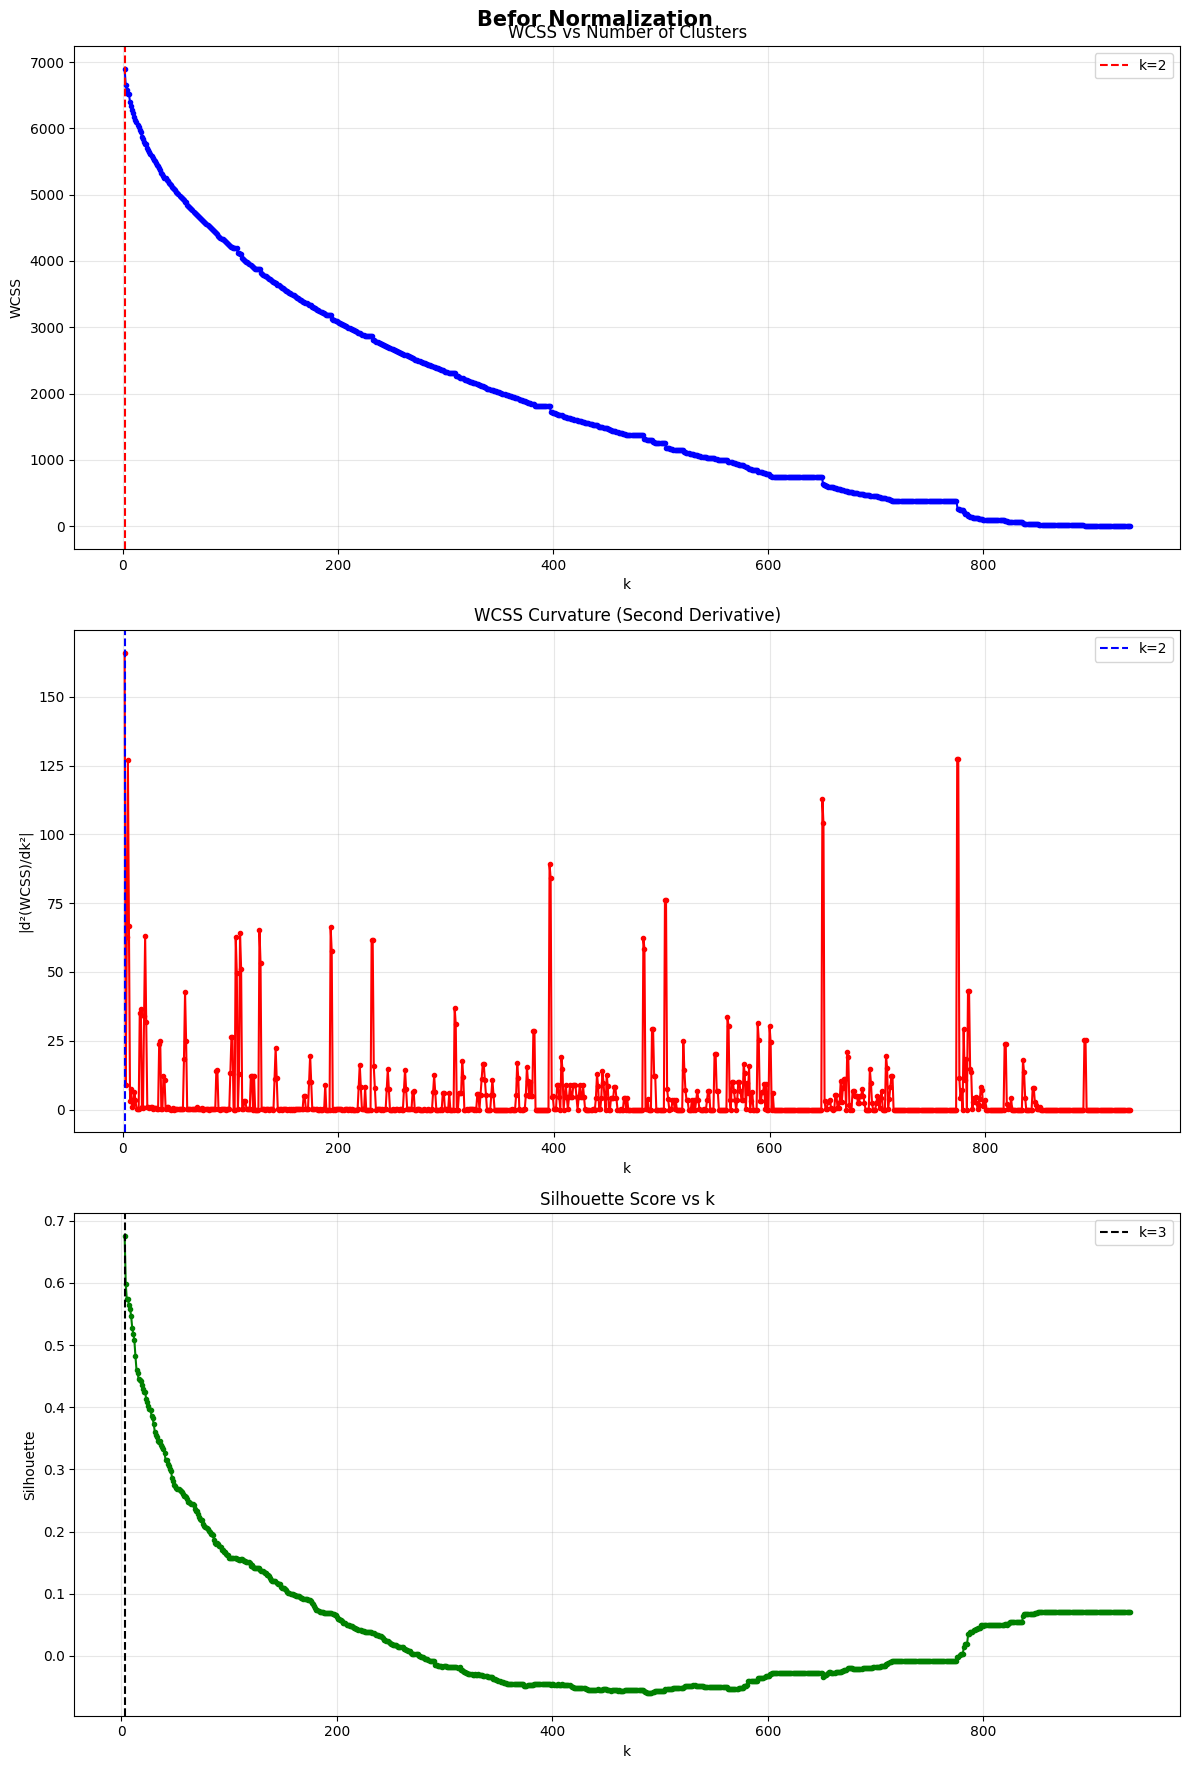

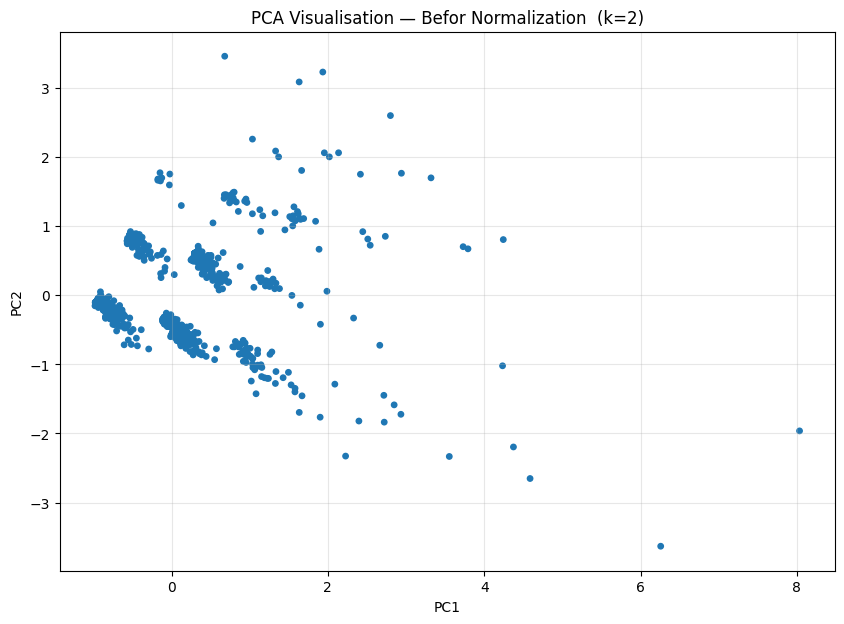

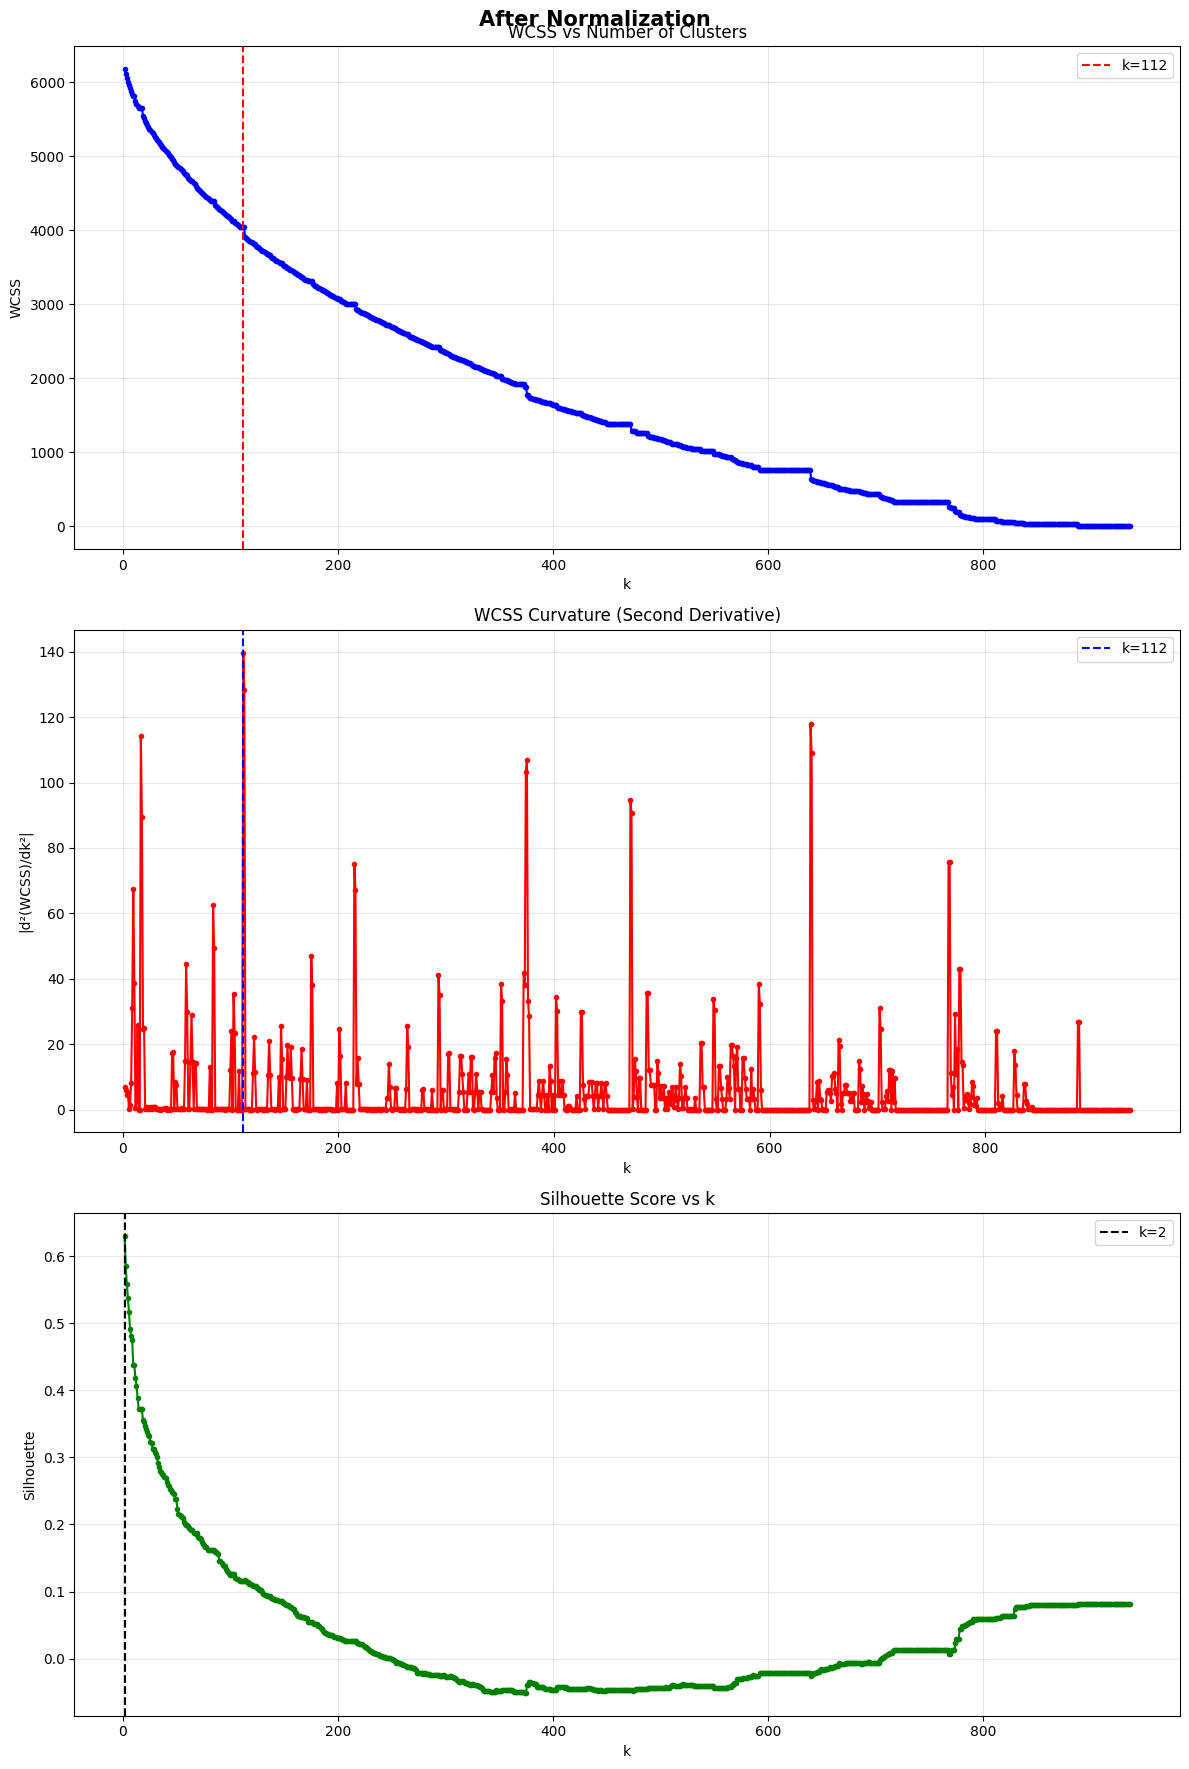

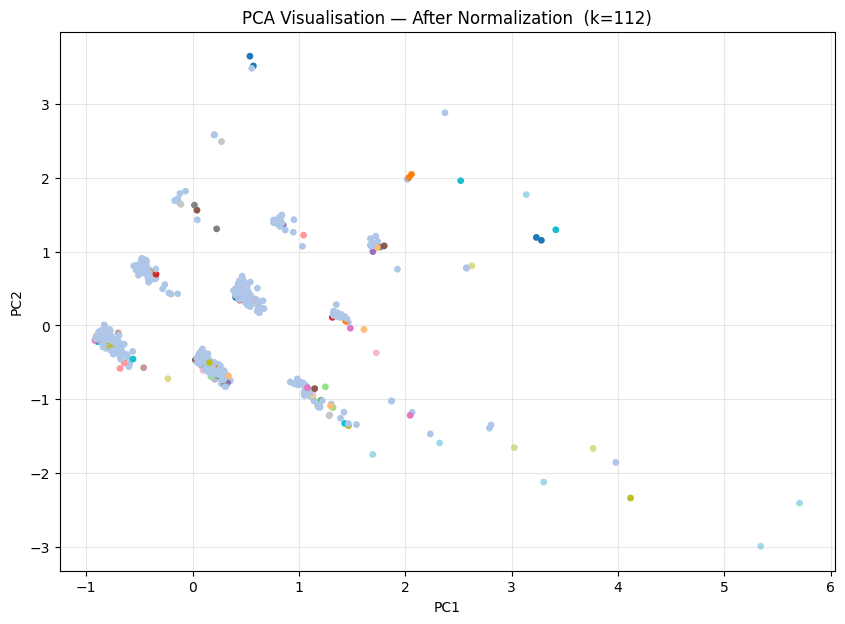

In [ ]:
# import matplotlib.pyplot as plt
# from scipy.cluster.hierarchy import linkage, fcluster
# from sklearn.metrics import silhouette_score
# from sklearn.decomposition import PCA

# VERSIONS = {
#     "Befor Normalization": vectors_dense_old,
#     "After Normalization":  vectors_scene_1,
# }
# N = vectors_dense_old.shape[0]-1
# k_list = list(range(N, 1, -1))

# results = {}

# for ver_name, vec in VERSIONS.items():
#     print(f"\n{'='*60}")
#     print(f"Running HAC for: {ver_name}  |  shape: {vec.shape}")
#     print('-'*60)

#     Z = linkage(vec, method='centroid', metric='euclidean')

#     wcss, sil = [], []
#     for k in k_list:
#         labels = fcluster(Z, t=k, criterion='maxclust')

#         # WCSS
#         total_var = 0.0
#         for cid in np.unique(labels):
#             pts = vec[labels == cid]
#             if pts.shape[0] <= 1:
#                 continue
#             cent = pts.mean(axis=0)
#             total_var += np.sum(np.linalg.norm(pts - cent, axis=1) ** 2)
#         wcss.append(total_var)

#         # Sil
#         if len(np.unique(labels)) >= 2:
#             sc = silhouette_score(vec, labels, metric='euclidean')
#         else:
#             sc = np.nan
#         sil.append(sc)

#     wcss = np.array(wcss)
#     sil  = np.array(sil)

#     first  = np.diff(wcss)
#     second = np.diff(first)
#     idx_curv = np.nanargmax(np.abs(second))
#     k_curv = k_list[idx_curv + 2]

#     valid_idx = np.where(~np.isnan(sil))[0]
#     k_sil = k_list[valid_idx[np.nanargmax(sil[valid_idx])]] if len(valid_idx) else None

#     print(f"Optimal K — WCSS Curvature: {k_curv}  |  Silhouette Max: {k_sil}")
#     results[ver_name] = {
#         'Z': Z, 'vec': vec, 'wcss': wcss, 'sil': sil,
#         'k_curv': k_curv, 'k_sil': k_sil
#     }

# for ver_name, res in results.items():
#     wcss   = res['wcss']
#     sil    = res['sil']
#     k_curv = res['k_curv']
#     k_sil  = res['k_sil']
#     Z      = res['Z']
#     vec    = res['vec']
#     second = np.diff(np.diff(wcss))

#     fig, axes = plt.subplots(3, 1, figsize=(12, 18))
#     fig.suptitle(ver_name, fontsize=15, fontweight='bold')

#     axes[0].plot(k_list, wcss, 'bo-', linewidth=1.5, markersize=3)
#     axes[0].axvline(k_curv, color='red', linestyle='--', label=f"k={k_curv}")
#     axes[0].set_title("WCSS vs Number of Clusters")
#     axes[0].set_xlabel("k"); axes[0].set_ylabel("WCSS")
#     axes[0].grid(alpha=0.3); axes[0].legend()

#     axes[1].plot(k_list[2:], np.abs(second), 'ro-', linewidth=1.5, markersize=3)
#     axes[1].axvline(k_curv, color='blue', linestyle='--', label=f"k={k_curv}")
#     axes[1].set_title("WCSS Curvature (Second Derivative)")
#     axes[1].set_xlabel("k"); axes[1].set_ylabel("|d²(WCSS)/dk²|")
#     axes[1].grid(alpha=0.3); axes[1].legend()

#     axes[2].plot(k_list, sil, 'go-', linewidth=1.5, markersize=3)
#     if k_sil:
#         axes[2].axvline(k_sil, color='black', linestyle='--', label=f"k={k_sil}")
#     axes[2].set_title("Silhouette Score vs k")
#     axes[2].set_xlabel("k"); axes[2].set_ylabel("Silhouette")
#     axes[2].grid(alpha=0.3); axes[2].legend()

#     plt.tight_layout()
#     plt.show()

#     k_optimal = k_curv
#     labels_opt = fcluster(Z, t=k_optimal, criterion='maxclust')
#     pca  = PCA(n_components=2)
#     vec2d = pca.fit_transform(vec)

#     plt.figure(figsize=(10, 7))
#     plt.scatter(vec2d[:, 0], vec2d[:, 1], c=labels_opt, cmap='tab20', s=15)
#     plt.title(f"PCA Visualisation — {ver_name}  (k={k_optimal})")
#     plt.xlabel("PC1"); plt.ylabel("PC2")
#     plt.grid(alpha=0.3)
#     plt.show()

In [ ]:
# def display_culster_details(tfidf_matrix, feature_names, labels, k, ver_name=""):
#     print(f"\n{'-'*30}")
#     print(f"Cluster Details — {ver_name}  (k={k})")
    
#     cluster_info = {}
    
#     for cluster_id in range(0, k):
#         indices = np.where(labels == cluster_id)[0]
        
#         if len(indices) == 0:
#             continue
        
#         cluster_data = tfidf_matrix[indices]
#         if hasattr(cluster_data, 'toarray'):
#             cluster_data = cluster_data.toarray()
#         cluster_mean = cluster_data.mean(axis=0)
#         threshold = cluster_mean.max() / 2
#         above_threshold = np.where(cluster_mean > threshold)[0]
#         sorted_idx = above_threshold[np.argsort(-cluster_mean[above_threshold])]
#         keywords = [(feature_names[i], cluster_mean[i]) for i in sorted_idx]
        
#         cluster_info[cluster_id] = {
#             'members': data_partial['processed_text'].iloc[indices].tolist(),
#             'count': len(indices),
#             'keywords': keywords
#         }
    
#     for cluster_id, info in cluster_info.items():
#         print(f"\nCluster {cluster_id}  ({info['count']} members)")
#         print(f"  Members: {info['members']}")
#         kw_str = ", ".join([f"{w}({s:.3f})" for w, s in info['keywords'][:10]])
#         print(f"  Keywords: {kw_str if kw_str else '—'}")
    
#     return cluster_info


# for ver_name, res in results.items():
#     labels_opt = fcluster(res['Z'], t=res['k_curv'], criterion='maxclust')
#     display_culster_details(
#         tfidf_matrix=res['vec'],
#         feature_names=(feature_names if ver_name == "Before Normalization" else feature_names_scene_1),
#         labels=labels_opt,
#         k=res['k_curv'],
#         ver_name=ver_name
#     )


------------------------------
Cluster Details — Befor Normalization  (k=2)

Cluster 1  (937 members)
  Members: ['maaf paham harga pasang pdam', 'rame nih', 'pdam jalan gresik mati', 'tugas wilayah ploso timur tolong kali cek air preman ketuk pagar ugal-ugalan kayu pentung preman pagar tetangga', 'kali kirim komplain langsung pecat tugas', 'terima kasih', 'pdam air hati alir tolong baik', 'kebraon susah aktivitas', 'laku', 'syarat lengkap proses pasang', 'karah mati air jam pemberitahuan tayamum', 'aju tanggal september keluar rincian tanggal september bayar batas bayar smp oktober harga promo agustus smp september promo', 'dm ya kak', 'rungkut industri air mati', 'pdam air keruh', 'kertaja kecil air', 'karang menjangan susah air bos', 'tagih pdam lonjak drastis', 'pdam wonorejo rungkut mati', 'adu gubris ya cs aja tugas air mati hari krn meter bocor habis ganti meter masalah', 'info ganggu air wilayah babat jerawat pondok benowo indah', 'lapor pdam gara-gara air jumat jam jam malam 

In [ ]:
        # if prev >= curr and nxt > curr:
        #     if (prev - curr) > threshold and (nxt - curr) > threshold:
        #         valley_k.append(k_list[i])